# Análise exploratória da tabela final (UF × mês)

**Projeto:** O que realmente move o preço da comida no Brasil? (SSC0957, Prática em Ciência de Dados II)
**Ticket:** [T-030](../tickets/03-analise/T-030-eda.md), com uma primeira visão bivariada que prepara o [T-031](../tickets/03-analise/T-031-correlacao-lag.md)

Os notebooks 06 a 08 construíram e justificaram a tabela `fato_alimentos_combustiveis_uf_mes.parquet`:
**2.088 linhas** (16 UFs × 138 meses, de 2015-01 a 2026-06, menos os meses em que AC, MA e SE ainda não
estavam no IPCA) e **108 colunas** de seis fontes. Este notebook olha para essa tabela **como um todo**,
antes de qualquer modelo.

Perguntas que guiam o notebook:

1. **O alvo** (`ipca_var_alimentacao`, a inflação de alimentos no mês): como ele se distribui, quando
   tem choques, que UFs sobem mais, tem sazonalidade, as UFs estão ficando mais parecidas?
2. **Os fatores** (clima, safra, seca, macro, combustíveis): como cada família se comporta, e qual recorte
   cada uma exige antes de ser usada.
3. **Primeira ligação** entre alvo e fatores: correlação contemporânea (no mesmo mês). As defasagens
   (CCF, lags ótimos, Granger) ficam para o T-031.

> **Sobre o alvo.** O T-030 foi escrito para a cesta do DIEESE (em R$). O alvo atual é uma **variação %**,
> então "nominal × real" vira "inflação de alimentos × inflação de alimentos **acima do IPCA geral**", e o
> "ranking de custo da cesta" vira um ranking de **inflação acumulada** numa janela comum.

Figuras salvas em `outputs/figuras/eda_*.png` (150 DPI). As três candidatas à apresentação estão marcadas
com ⭐ no fim.

In [ ]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

# Acha a raiz do repositório, de onde quer que o notebook tenha sido aberto.
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
TABELAS = RAIZ / "outputs" / "tabelas"
FIGURAS = RAIZ / "outputs" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)
ARQ_FATO = RAIZ / "data" / "processed" / "fato_alimentos_combustiveis_uf_mes.parquet"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

# Mesma identidade visual do notebook 08: uma cor fixa por família de colunas.
CORES = {
    "ipca": "#2a78d6",   # IBGE/SIDRA
    "clima": "#eb6834",  # INMET
    "safra": "#1baf7a",  # IBGE/LSPA
    "seca": "#eda100",   # ANA
    "macro": "#e87ba4",  # BCB
    "comb": "#008300",   # ANP
}
NEUTRO = "#c3c2b7"
TINTA, TINTA_2, TINTA_3 = "#0b0b0b", "#52514e", "#898781"
FUNDO = "#fcfcfb"

# Regiões: as cinco primeiras posições da paleta categórica, sempre nesta ordem
# (a cor segue a região, nunca a posição no ranking).
REGIOES = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
CORES_REGIAO = dict(zip(REGIOES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))

# Escala divergente: azul abaixo de zero, vermelho acima, cinza neutro no meio.
DIVERGENTE = LinearSegmentedColormap.from_list(
    "divergente", ["#104281", "#3987e5", "#f0efec", "#e66767", "#a8292a"]
).with_extremes(bad="#ffffff")
# Escala sequencial: um só matiz (azul), do claro ao escuro.
SEQUENCIAL = LinearSegmentedColormap.from_list("sequencial", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])

plt.rcParams.update({
    "figure.figsize": (11, 3.8), "figure.dpi": 110,
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO, "savefig.facecolor": FUNDO,
    "axes.edgecolor": NEUTRO, "axes.labelcolor": TINTA_2, "text.color": TINTA,
    "xtick.color": TINTA_3, "ytick.color": TINTA_3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 9.5, "lines.linewidth": 2, "legend.frameon": False,
})

FONTES = {
    "ipca": "IBGE/SIDRA, IPCA (tabelas 1419 e 7060)",
    "clima": "INMET/BDMEP, mediana das estações da UF",
    "safra": "IBGE/LSPA (tabela 6588)",
    "seca": "ANA, Monitor de Secas",
    "macro": "BCB/SGS (séries 1, 189, 432 e 433)",
    "comb": "ANP, Levantamento de Preços de Combustíveis",
}


def salvar(fig, nome, *familias):
    """Carimba a fonte no rodapé e salva em outputs/figuras/eda_<nome>.png (150 DPI)."""
    texto = "Fonte: " + "; ".join(FONTES[f] for f in familias) + ". Elaboração: Grupo 1 (SSC0957)."
    fig.text(0.0, -0.01, texto, ha="left", va="top", fontsize=7.5, color=TINTA_3)
    caminho = FIGURAS / f"eda_{nome}.png"
    fig.savefig(caminho, dpi=150, bbox_inches="tight")
    print(f"figura salva: {caminho.relative_to(RAIZ)}")


def eixo_tempo(ax, passo=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(passo))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="x", visible=False)


# Episódios conhecidos, para dar contexto às séries (sombreados, não são dados).
EVENTOS = [
    ("2015-10", "2016-06", "seca no NE", 0.97),
    ("2019-11", "2019-12", "carne (China)", 0.86),
    ("2020-03", "2021-03", "pandemia + câmbio", 0.97),
    ("2021-06", "2021-11", "seca no Centro-Sul", 0.86),
    ("2024-08", "2025-05", "alta do café", 0.97),
]


def marcar_eventos(ax, rotulos=True):
    for ini, fim, nome, y in EVENTOS:
        a = pd.Period(ini, "M").to_timestamp()
        b = pd.Period(fim, "M").to_timestamp(how="end")
        ax.axvspan(a, b, color="#efeee9", zorder=0, linewidth=0)
        if rotulos:
            ax.text(a, y, " " + nome, transform=ax.get_xaxis_transform(), ha="left", va="top",
                    fontsize=7.5, color=TINTA_2)


MESES_ABREV = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]
print(f"raiz do projeto: {RAIZ}")

raiz do projeto: /home/tur1sm0/Documents/GitHub/trabalho_pcd2


---
## Parte 0: carregar e conferir o contrato

Antes de qualquer gráfico, o notebook confere que a tabela é a que os notebooks 06 a 08 entregaram. Se
algo mudou (outra coleta, outra junção), ele **para aqui**, em vez de produzir figuras erradas em
silêncio.

Também converte `seca_meses_consecutivos_S2plus` do tipo `Float64` (com `pd.NA`) para `float64` comum:
sem isso, `corr()` e `spearmanr` quebram.

In [2]:
fato = pd.read_parquet(ARQ_FATO).sort_values(["sigla_uf", "ano_mes"]).reset_index(drop=True)

assert len(fato) == 2088, f"esperava 2.088 linhas, veio {len(fato)}"
assert not fato.duplicated(["sigla_uf", "ano_mes"]).any(), "chave (sigla_uf, ano_mes) duplicada"
assert fato["sigla_uf"].nunique() == 16 and fato["ano_mes"].nunique() == 138
assert isinstance(fato["ano_mes"].dtype, pd.PeriodDtype), "ano_mes deveria ser Period[M]"
assert (fato["ipca_var_alimentacao"] < 0).any(), "nenhuma variação negativa: o bug do sinal do IPCA voltou"

fato["seca_meses_consecutivos_S2plus"] = fato["seca_meses_consecutivos_S2plus"].astype("float64")
fato["data"] = fato["ano_mes"].dt.to_timestamp()  # para o eixo dos gráficos

# Dicionário de variáveis (está no Git): unidade, fonte e justificativa de nulos de cada coluna.
dic = pd.read_csv(TABELAS / "dicionario_variaveis_combustiveis.csv").set_index("coluna")
sem_dic = sorted(set(fato.columns) - set(dic.index) - {"data"})
print(f"{len(fato):,} linhas × {fato.shape[1] - 1} colunas · {fato['ano_mes'].min()} a {fato['ano_mes'].max()}")
print(f"colunas sem entrada no dicionário: {sem_dic or 'nenhuma'}")

# Ordem fixa das UFs (por região) e a grade completa 16 UFs × 138 meses, com buracos explícitos.
ufs = fato[["sigla_uf", "regiao"]].drop_duplicates()
ufs["ordem"] = ufs["regiao"].map({r: i for i, r in enumerate(REGIOES)})
ORDEM_UF = ufs.sort_values(["ordem", "sigla_uf"])["sigla_uf"].tolist()
REGIAO_DA_UF = dict(zip(ufs["sigla_uf"], ufs["regiao"]))
MESES = pd.period_range(fato["ano_mes"].min(), fato["ano_mes"].max(), freq="M")
grade = fato.set_index(["sigla_uf", "ano_mes"]).reindex(
    pd.MultiIndex.from_product([ORDEM_UF, MESES], names=["sigla_uf", "ano_mes"])
)

por_uf = fato.groupby("sigla_uf").agg(regiao=("regiao", "first"), primeiro_mes=("ano_mes", "min"),
                                      meses=("ano_mes", "size")).loc[ORDEM_UF]
display(por_uf.T)

2,088 linhas × 108 colunas · 2015-01 a 2026-06
colunas sem entrada no dicionário: nenhuma


sigla_uf,AC,PA,BA,CE,MA,PE,SE,DF,GO,MS,ES,MG,RJ,SP,PR,RS
regiao,Norte,Norte,Nordeste,Nordeste,Nordeste,Nordeste,Nordeste,Centro-Oeste,Centro-Oeste,Centro-Oeste,Sudeste,Sudeste,Sudeste,Sudeste,Sul,Sul
primeiro_mes,2018-05,2015-01,2015-01,2015-01,2018-05,2015-01,2018-05,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01,2015-01
meses,98,138,138,138,98,138,98,138,138,138,138,138,138,138,138,138


---
## Parte 1: o que tem na tabela, e onde ela é vazia

Cada coluna pertence a uma **família**, identificada pelo prefixo (`ipca_`, `clima_`, `safra_`, `seca_`,
`macro_`, `comb_`). A cor de cada família é a mesma em todos os gráficos deste notebook.

In [3]:
def familia(col):
    for f in CORES:
        if col.startswith(f + "_"):
            return f
    return "chave"


perfil = pd.DataFrame(
    {"familia": [familia(c) for c in fato.columns], "pct_nulos": fato.isna().mean() * 100},
    index=fato.columns,
).drop(index="data")

resumo = perfil.groupby("familia").agg(
    colunas=("pct_nulos", "size"),
    colunas_com_nulos=("pct_nulos", lambda s: int((s > 0).sum())),
    pior_coluna_pct_nulos=("pct_nulos", "max"),
).round(1).loc[["chave", *CORES]]
display(resumo)

,colunas,colunas_com_nulos,pior_coluna_pct_nulos
familia,,,
chave,6,0,0.0
ipca,36,1,1.6
clima,11,10,0.3
safra,22,11,52.7
seca,9,8,38.2
macro,5,0,0.0
comb,19,17,39.2


figura salva: outputs/figuras/eda_01_nulos_por_coluna.png


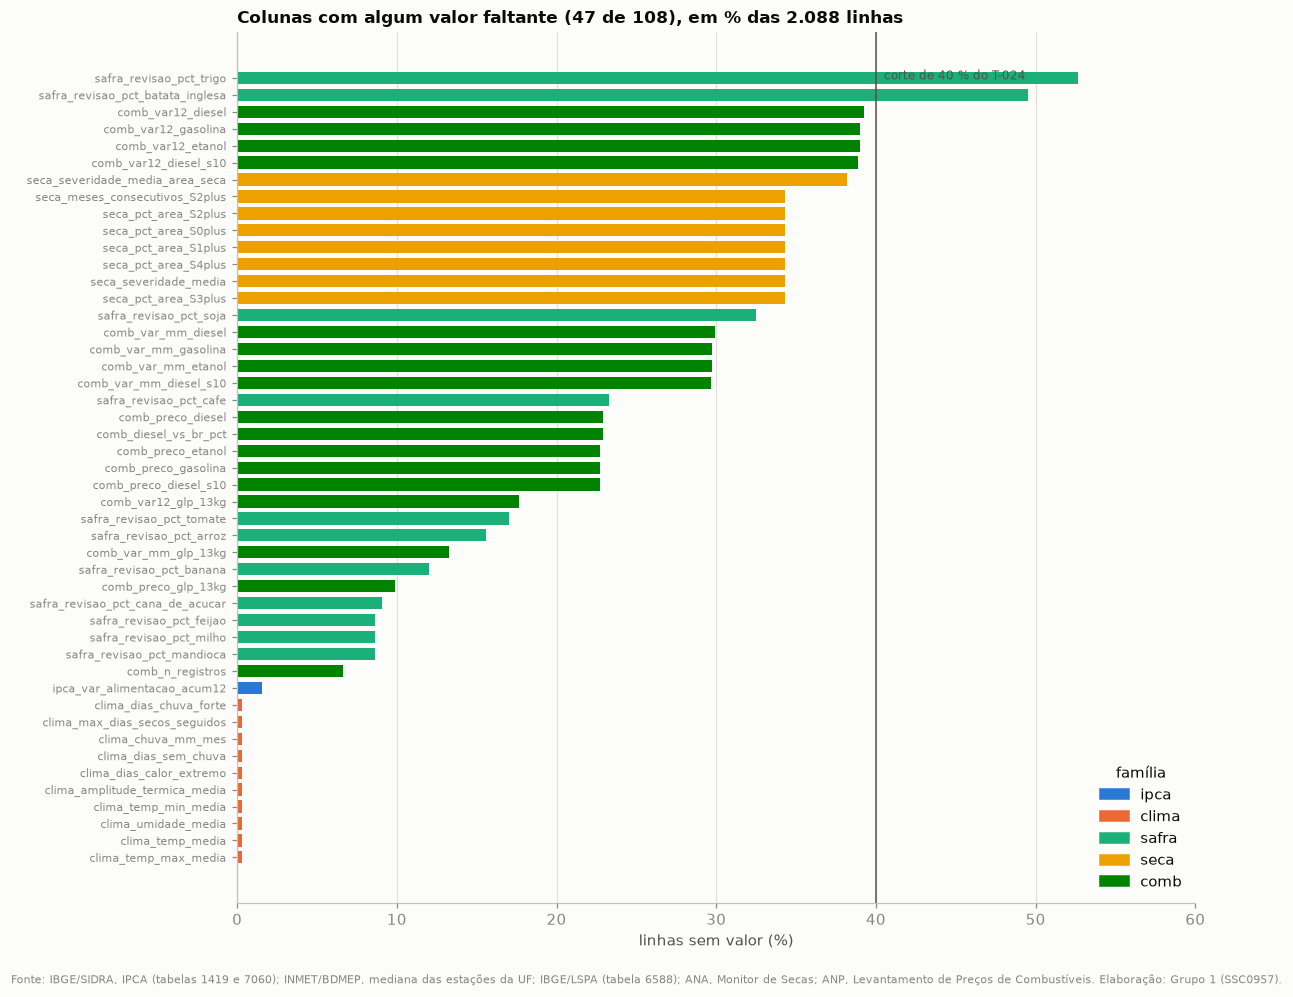

Justificativa registrada no dicionário para as colunas acima de 40 %:

· safra_revisao_pct_batata_inglesa (49.5 %): NaN em safra_revisao_pct_* é indefinição, não falta: janeiro não tem mês anterior dentro da mesma safra, e a UF que não planta o produto não tem estimativa para revisar. As colunas safra_producao_t_* não têm nulo porque a ausência estrutural virou 0 tonelada.

· safra_revisao_pct_trigo (52.7 %): NaN em safra_revisao_pct_* é indefinição, não falta: janeiro não tem mês anterior dentro da mesma safra, e a UF que não planta o produto não tem estimativa para revisar. As colunas safra_producao_t_* não têm nulo porque a ausência estrutural virou 0 tonelada.


In [4]:
nulos = perfil[perfil["pct_nulos"] > 0].sort_values("pct_nulos")

fig, ax = plt.subplots(figsize=(11, 0.16 * len(nulos) + 1.3))
ax.barh(nulos.index, nulos["pct_nulos"], color=[CORES[f] for f in nulos["familia"]], height=0.72)
ax.axvline(40, color=TINTA_2, linewidth=1)
ax.text(40.5, len(nulos) - 0.5, "corte de 40 % do T-024", va="top", fontsize=8, color=TINTA_2)
ax.set_xlim(0, 60)
ax.set_xlabel("linhas sem valor (%)")
ax.tick_params(axis="y", labelsize=7.2)
ax.grid(axis="y", visible=False)
presentes = [f for f in CORES if f in set(nulos["familia"])]
ax.legend(handles=[Patch(color=CORES[f], label=f) for f in presentes], loc="lower right", title="família")
ax.set_title(f"Colunas com algum valor faltante ({len(nulos)} de {len(perfil)}), em % das 2.088 linhas")
plt.tight_layout()
salvar(fig, "01_nulos_por_coluna", "ipca", "clima", "safra", "seca", "comb")
plt.show()

acima = nulos[nulos["pct_nulos"] > 40].index
print("Justificativa registrada no dicionário para as colunas acima de 40 %:")
for c in acima:
    print(f"\n· {c} ({nulos.loc[c, 'pct_nulos']:.1f} %): {dic.loc[c, 'observacao']}")

**Leitura:** as colunas-chave, as macro e quase todo o IPCA estão completas. A única exceção do IPCA é o
acumulado em 12 meses, com 1,6 % de nulos: são os 12 primeiros meses de cada UF. Os nulos se concentram em
três famílias, cada uma por um motivo próprio:

- **safra:** revisão indefinida em janeiro e onde a UF não planta o produto;
- **seca:** UF ainda fora do Monitor, de 34 % a 38 %;
- **combustíveis:** meses sem pesquisa da ANP, de 7 % a 39 %.

Só duas colunas passam do corte de 40 % do T-024: a revisão da safra de **batata-inglesa** (49,5 %) e a de
**trigo** (52,7 %). As duas têm justificativa no dicionário: ali o nulo quer dizer "a UF não planta isso",
não falha de coleta.

### Onde ficam os buracos

A % de nulos esconde **onde** eles estão. O mapa abaixo mostra as três lacunas estruturais da tabela,
cada uma com causa diferente:

- **IPCA:** AC, MA e SE só entram no IPCA em 2018-05. Antes disso, essas linhas **não existem** na tabela
  (branco), o que deixa o painel desbalanceado.
- **Seca:** a ANA foi incluindo UFs no Monitor aos poucos. Cinza claro = a linha existe, mas a UF ainda
  não era monitorada.
- **Combustíveis:** há meses inteiros sem pesquisa da ANP, nos mesmos meses para todas as UFs.

figura salva: outputs/figuras/eda_02_mapa_de_cobertura.png


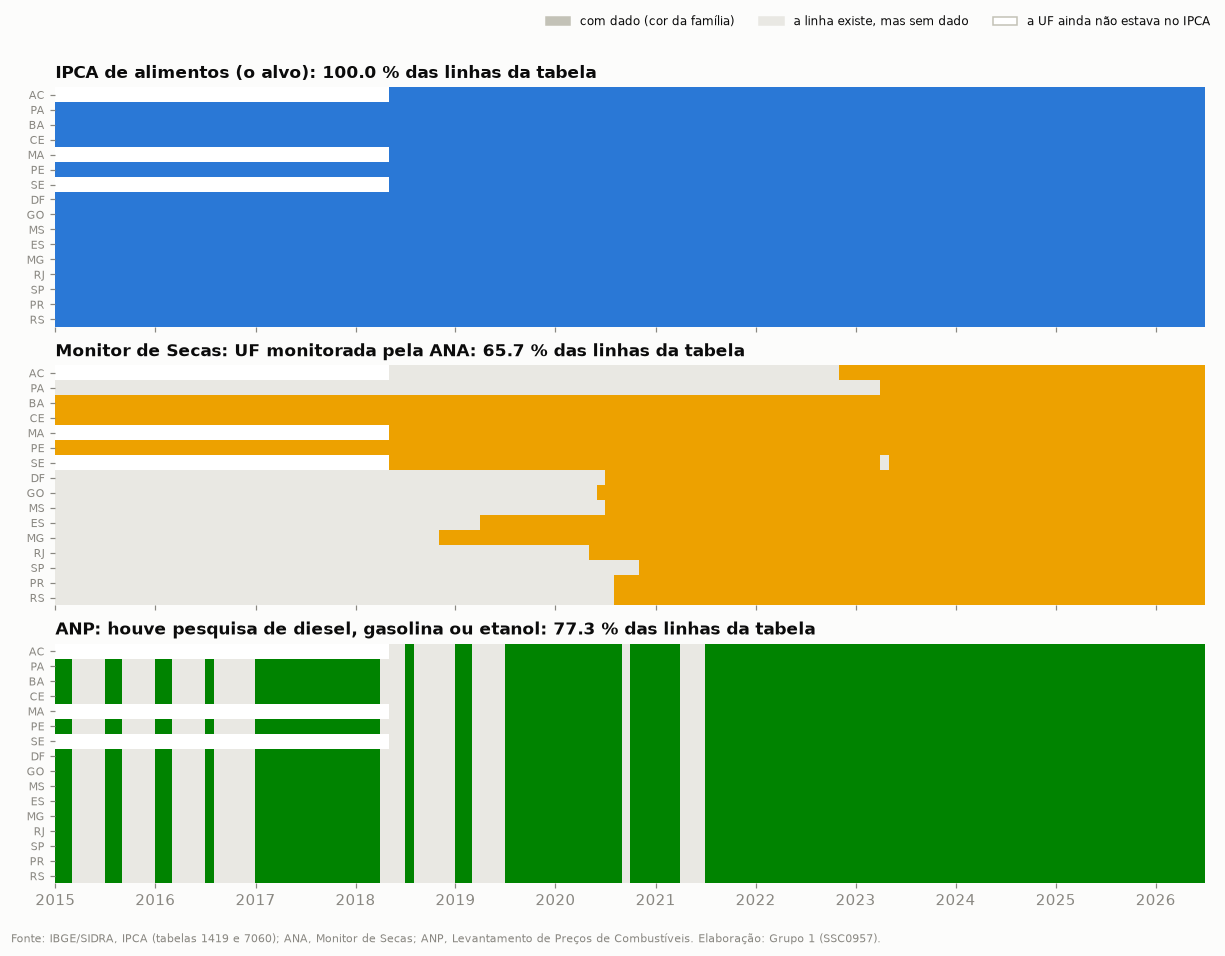

meses sem pesquisa de combustível líquido em NENHUMA UF: 33 de 138
seca monitorada, por recorte: {'2015-01+': '65.7 %', '2018-01+': '78.0 %', '2020-01+': '90.5 %', '2022-01+': '97.0 %', '2024-01+': '100.0 %'}


In [5]:
existe = grade["ipca_var_alimentacao"].notna()
paineis = [
    ("IPCA de alimentos (o alvo)", existe, CORES["ipca"]),
    ("Monitor de Secas: UF monitorada pela ANA", grade["seca_monitorado"].eq(True), CORES["seca"]),
    ("ANP: houve pesquisa de diesel, gasolina ou etanol", grade["comb_observado_liquidos"].eq(True), CORES["comb"]),
]
x0 = mdates.date2num(MESES[0].to_timestamp())
x1 = mdates.date2num((MESES[-1] + 1).to_timestamp())

fig, axes = plt.subplots(3, 1, figsize=(11, 8.2), sharex=True)
for ax, (titulo, ok, cor) in zip(axes, paineis):
    estado = np.where(~existe, 0, np.where(ok, 2, 1)).reshape(len(ORDEM_UF), len(MESES))
    ax.imshow(estado, aspect="auto", interpolation="nearest", vmin=0, vmax=2,
              cmap=ListedColormap(["#ffffff", "#e9e8e3", cor]), extent=[x0, x1, len(ORDEM_UF), 0])
    ax.set_yticks(np.arange(len(ORDEM_UF)) + 0.5, ORDEM_UF, fontsize=7.5)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    pct = ok[existe].mean() * 100
    ax.set_title(f"{titulo}: {pct:.1f} % das linhas da tabela")
axes[-1].xaxis_date()
eixo_tempo(axes[-1], passo=1)
fig.legend(
    handles=[Patch(color=NEUTRO, label="com dado (cor da família)"),
             Patch(color="#e9e8e3", label="a linha existe, mas sem dado"),
             Patch(facecolor="#ffffff", edgecolor=NEUTRO, label="a UF ainda não estava no IPCA")],
    loc="upper right", ncol=3, bbox_to_anchor=(1.0, 1.02), fontsize=8,
)
plt.tight_layout(rect=(0, 0, 1, 0.97))
salvar(fig, "02_mapa_de_cobertura", "ipca", "seca", "comb")
plt.show()

sem_pesquisa = (~fato.groupby("ano_mes")["comb_observado_liquidos"].any())
print(f"meses sem pesquisa de combustível líquido em NENHUMA UF: {int(sem_pesquisa.sum())} de 138")
print("seca monitorada, por recorte:",
      {f"{a}+": f"{fato.loc[fato['ano_mes'] >= pd.Period(a, 'M'), 'seca_monitorado'].mean() * 100:.1f} %"
       for a in ["2015-01", "2018-01", "2020-01", "2022-01", "2024-01"]})

**Leitura:** o alvo cobre 100 % por construção (a tabela só tem linha onde há IPCA). Mesmo assim, o
**painel é desbalanceado**: 13 UFs têm 138 meses, e AC, MA e SE têm 98.

- **Seca:** a cobertura cresce em degraus. É de 65,7 % das linhas no painel inteiro, **90,5 % a partir de
  2020-01** e 100 % a partir de 2024. Esse é o recorte já decidido na junção.
- **Combustíveis:** os buracos são **colunas inteiras**, isto é, os mesmos 33 meses sem pesquisa em
  nenhuma UF. Eles se concentram entre 2015 e o 1º semestre de 2021; daí em diante a série é contínua. Uma
  análise com defasagem de combustível perde mais do que esses 33 meses, porque a variação também exige o
  mês anterior.

---
## Parte 2: o alvo, `ipca_var_alimentacao`

É a variação % no mês do grupo **Alimentação e bebidas** do IPCA, por área urbana (UF). Tudo nesta parte
é sobre ele e os dois alvos derivados:

| Coluna | O que é |
|---|---|
| `ipca_var_alimentacao` | variação % no mês (**alvo principal**) |
| `ipca_var_alimentacao_acum12` | acumulado em 12 meses, composto, por UF |
| `ipca_var_alimentacao_relativa` | variação no mês **menos** o IPCA geral do Brasil no mês: quanto a comida subiu além da inflação |

### 2.1 Como a variação mensal se distribui

n = 2,088 UF-meses
média 0.56 % · mediana 0.49 % · desvio-padrão 0.94 pp
mín -1.95 % · máx 4.74 % · meses negativos: 29.7 %
assimetria 0.60 · curtose em excesso 0.80
Jarque-Bera = 181.1 (p = 4.6e-40) · Shapiro-Wilk W = 0.981 (p = 3.9e-16)
figura salva: outputs/figuras/eda_03_distribuicao_alvo.png


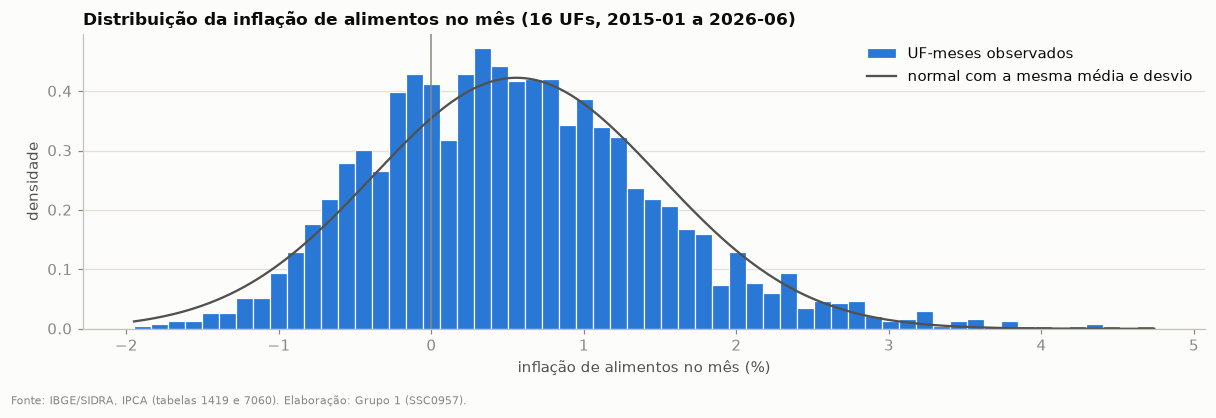

In [6]:
y = fato["ipca_var_alimentacao"]
jb = stats.jarque_bera(y)
sw = stats.shapiro(y)
print(f"n = {len(y):,} UF-meses")
print(f"média {y.mean():.2f} % · mediana {y.median():.2f} % · desvio-padrão {y.std():.2f} pp")
print(f"mín {y.min():.2f} % · máx {y.max():.2f} % · meses negativos: {(y < 0).mean() * 100:.1f} %")
print(f"assimetria {stats.skew(y):.2f} · curtose em excesso {stats.kurtosis(y):.2f}")
print(f"Jarque-Bera = {jb.statistic:.1f} (p = {jb.pvalue:.1e}) · Shapiro-Wilk W = {sw.statistic:.3f} (p = {sw.pvalue:.1e})")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.hist(y, bins=60, color=CORES["ipca"], edgecolor=FUNDO, linewidth=0.8, density=True,
        label="UF-meses observados")
xs = np.linspace(y.min(), y.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, y.mean(), y.std()), color=TINTA_2, linewidth=1.5,
        label="normal com a mesma média e desvio")
ax.axvline(0, color=TINTA_3, linewidth=1)
ax.set_xlabel("inflação de alimentos no mês (%)")
ax.set_ylabel("densidade")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
ax.set_title("Distribuição da inflação de alimentos no mês (16 UFs, 2015-01 a 2026-06)")
plt.tight_layout()
salvar(fig, "03_distribuicao_alvo", "ipca")
plt.show()

**Leitura:** a inflação de alimentos no mês tem média de 0,56 % e mediana de 0,49 %, e **29,7 % dos
UF-meses são negativos**. Deflação de comida é comum, e isso também prova que o bug do sinal está
corrigido.

A distribuição tem **cauda à direita** (assimetria de 0,60 e curtose em excesso de 0,80): altas fortes
(até 4,74 %) são mais frequentes e maiores que quedas fortes (mínimo de −1,95 %). Jarque-Bera e
Shapiro-Wilk rejeitam a normalidade com folga. Para a modelagem, isso quer dizer duas coisas: evitar
métodos que suponham alvo normal, e esperar que os maiores erros de um modelo fiquem nos meses de alta.

### 2.2 Meses de choque

Um **choque** aqui é um mês em que a UF ficou a mais de 2 desvios-padrão da **sua própria** média
(z-score por UF), para não marcar como choque o que é só o nível normal de uma UF mais cara. Quando
muitas UFs têm choque no mesmo mês, o choque é **nacional**. A lista completa vai para
`outputs/tabelas/eda_choques_alvo.csv` (insumo do T-031).

In [7]:
z = fato.groupby("sigla_uf")["ipca_var_alimentacao"].transform(lambda s: (s - s.mean()) / s.std())
choques = fato.loc[z.abs() >= 2, ["ano_mes", "sigla_uf", "regiao", "ipca_var_alimentacao"]].assign(z=z.round(2))
choques = choques.sort_values(["ano_mes", "sigla_uf"])
choques.to_csv(TABELAS / "eda_choques_alvo.csv", index=False)
print(f"{len(choques)} UF-meses de choque ({(choques['z'] > 0).sum()} de alta, {(choques['z'] < 0).sum()} de queda) "
      f"→ {(TABELAS / 'eda_choques_alvo.csv').relative_to(RAIZ)}")

por_mes = choques.groupby("ano_mes").agg(
    ufs_em_choque=("sigla_uf", "size"),
    sentido=("z", lambda s: "alta" if s.mean() > 0 else "queda"),
    variacao_media=("ipca_var_alimentacao", "mean"),
    ufs=("sigla_uf", lambda s: ", ".join(s)),
).round(2)
display(por_mes.sort_values(["ufs_em_choque", "variacao_media"], ascending=False).head(12))

88 UF-meses de choque (73 de alta, 15 de queda) → outputs/tabelas/eda_choques_alvo.csv


,ufs_em_choque,sentido,variacao_media,ufs
ano_mes,,,,
2019-12,15,alta,3.62,"BA, CE, DF, ES, GO, MA, MG, MS, PA, PE, PR, RJ, RS, SE, SP"
2020-09,9,alta,3.13,"AC, CE, ES, GO, MG, MS, PE, RJ, SE"
2020-11,9,alta,3.08,"AC, CE, ES, GO, MA, MG, MS, RJ, SP"
2016-01,6,alta,3.12,"BA, CE, ES, GO, PE, RJ"
2022-03,6,alta,2.70,"DF, ES, PA, PR, RS, SP"
2020-10,4,alta,3.31,"AC, ES, MA, MG"
2017-08,4,queda,-1.54,"GO, MG, PA, SP"
2020-12,3,alta,3.13,"MA, RJ, RS"
2015-11,3,alta,2.89,"BA, GO, MS"


**Leitura:** são 88 UF-meses de choque, **73 de alta e só 15 de queda**: os choques da comida são
assimétricos.

- **2019-12 é o maior choque nacional:** 15 das 16 UFs ao mesmo tempo, com a carne subindo 17 % no mês
  (mediana das UFs), na esteira da demanda chinesa por carne.
- **2020-09 a 2020-11:** pandemia com real desvalorizado; batata e tomate dispararam.
- **2016-01:** seca no Nordeste.
- **2022-03:** coincide com o início da guerra na Ucrânia.

Só um desses episódios tem origem climática clara. É uma primeira pista de que, no curto prazo, o clima não é o
maior motor do alvo. A lista vai para o T-031: são esses meses que um modelo precisa conseguir explicar.

### 2.3 A série no tempo

Primeiro, a variação mensal: a **mediana** das UFs e a faixa entre elas. Depois, o acumulado em 12 meses,
com uma UF de cada região em destaque e as demais em cinza. As faixas sombreadas marcam episódios
conhecidos; são contexto, não dado.

figura salva: outputs/figuras/eda_04_alvo_mensal_mediana.png


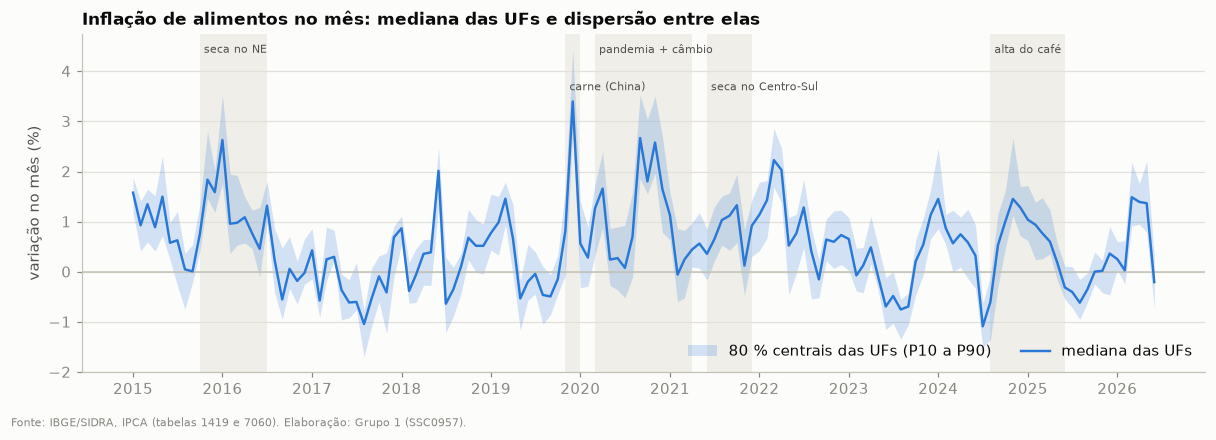

In [8]:
q = fato.groupby("data")["ipca_var_alimentacao"].quantile([0.1, 0.5, 0.9]).unstack()

fig, ax = plt.subplots(figsize=(11, 3.8))
marcar_eventos(ax)
ax.axhline(0, color=NEUTRO, linewidth=1)
ax.fill_between(q.index, q[0.1], q[0.9], color=CORES["ipca"], alpha=0.2, linewidth=0,
                label="80 % centrais das UFs (P10 a P90)")
ax.plot(q.index, q[0.5], color=CORES["ipca"], linewidth=1.6, label="mediana das UFs")
ax.set_ylabel("variação no mês (%)")
eixo_tempo(ax, passo=1)
ax.legend(loc="lower right", ncol=2)
ax.set_title("Inflação de alimentos no mês: mediana das UFs e dispersão entre elas")
plt.tight_layout()
salvar(fig, "04_alvo_mensal_mediana", "ipca")
plt.show()

figura salva: outputs/figuras/eda_05_alvo_acum12_por_uf.png


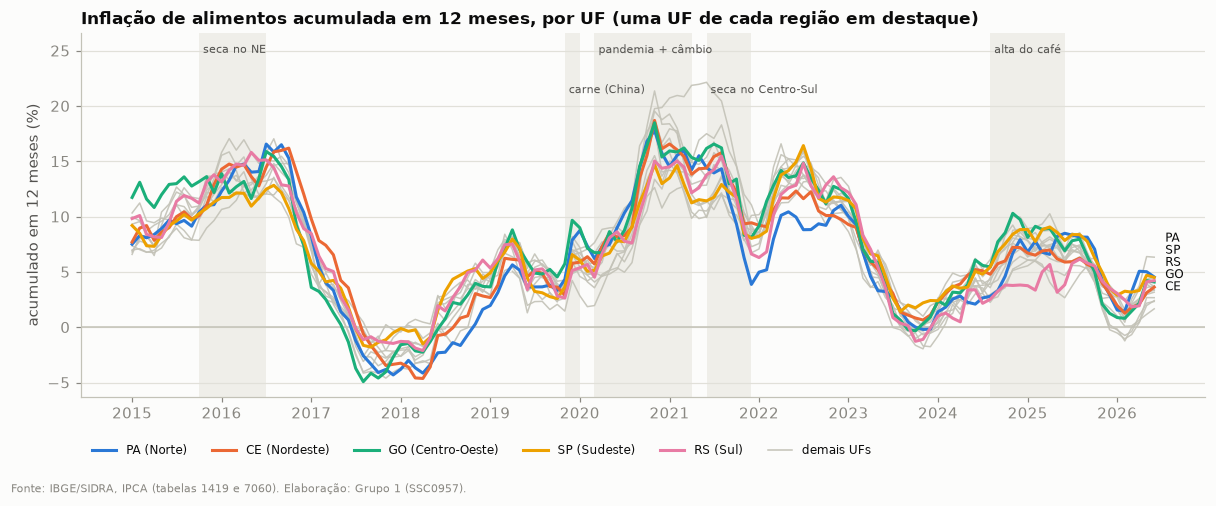

parcela da variância da inflação mensal explicada só por o mês (efeito comum a todas as UFs): 73.2 %
parcela da variância da inflação mensal explicada só por a UF (nível próprio de cada UF): 0.1 %


In [9]:
DESTAQUE = {"PA": "Norte", "CE": "Nordeste", "GO": "Centro-Oeste", "SP": "Sudeste", "RS": "Sul"}
acum = fato.pivot(index="data", columns="sigla_uf", values="ipca_var_alimentacao_acum12")

fig, ax = plt.subplots(figsize=(11, 4.4))
marcar_eventos(ax)
ax.axhline(0, color=NEUTRO, linewidth=1)
for uf in acum.columns.difference(list(DESTAQUE)):
    ax.plot(acum.index, acum[uf], color=NEUTRO, linewidth=1, alpha=0.9)
finais = {}
for uf, reg in DESTAQUE.items():
    s = acum[uf].dropna()
    ax.plot(s.index, s, color=CORES_REGIAO[reg], linewidth=2, label=f"{uf} ({reg})")
    finais[uf] = (s.index[-1], s.iloc[-1])
# Rótulos diretos no fim das linhas, afastados para não se sobreporem.
y_rot = []
for uf, (x, v) in sorted(finais.items(), key=lambda kv: kv[1][1]):
    v_rot = max(v, y_rot[-1] + 1.1) if y_rot else v
    y_rot.append(v_rot)
    ax.annotate(uf, (mdates.date2num(x), v), xytext=(mdates.date2num(x) + 45, v_rot), va="center",
                fontsize=8, color=TINTA)
ax.set_ylim(top=acum.max().max() * 1.2)
ax.set_ylabel("acumulado em 12 meses (%)")
eixo_tempo(ax, passo=1)
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], color=NEUTRO, linewidth=1))
labels.append("demais UFs")
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.0, -0.1), ncol=6, fontsize=8)
ax.set_title("Inflação de alimentos acumulada em 12 meses, por UF (uma UF de cada região em destaque)")
plt.tight_layout()
salvar(fig, "05_alvo_acum12_por_uf", "ipca")
plt.show()

# Quanto da variação do alvo é "do mês" (comum a todas as UFs) e quanto é "da UF"?
alvo = fato["ipca_var_alimentacao"]
total = ((alvo - alvo.mean()) ** 2).sum()
for chave, nome in [("ano_mes", "o mês (efeito comum a todas as UFs)"), ("sigla_uf", "a UF (nível próprio de cada UF)")]:
    media = fato.groupby(chave)["ipca_var_alimentacao"].transform("mean")
    print(f"parcela da variância da inflação mensal explicada só por {nome}: "
          f"{(1 - ((alvo - media) ** 2).sum() / total) * 100:.1f} %")

**Leitura:** **as UFs se movem juntas.** A faixa entre as UFs é estreita em volta da mediana, e os picos
(2016-01, 2019-12, 2020-09/11, 2022-03) aparecem no país inteiro. A conta do fim da célula põe número
nisso: **73 % da variância da inflação mensal é explicada só pelo mês** (o que é comum a todas as UFs), e
só 0,1 % pela UF.

No acumulado em 12 meses há quatro fases:

- alta em 2015-16 (até ~16 %);
- **deflação em 2017-18** (até −5 %);
- o grande ciclo de 2020-22 (até ~22 %);
- uma alta menor em 2024-25 (~8 % a 10 %).

As cinco UFs em destaque quase se sobrepõem. Isso antecipa a principal dificuldade do trabalho: a
pergunta é sobre volatilidade **regional**, mas a maior parte do sinal do alvo é **nacional**. O que
sobra para explicar entre UFs são os ~27 % restantes.

### 2.4 Comida × inflação geral

Esta é a tradução do "nominal × real" do T-030. Como o alvo já é uma variação %, a pergunta útil é:
**a comida sobe mais ou menos que o resto dos preços?** As duas séries estão na mesma unidade (% em 12
meses), então dividem um só eixo.

figura salva: outputs/figuras/eda_06_alimentos_vs_ipca_geral.png


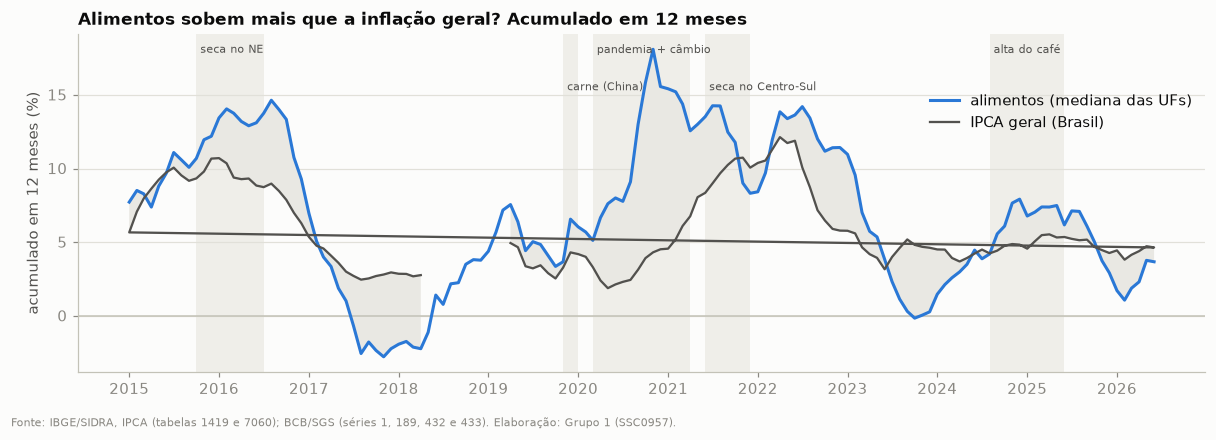

meses (UF-mês) em que a comida subiu acima do IPCA geral: 51.5 %
diferença média: +0.10 pp por mês · mediana +0.04 pp
maior folga da comida sobre o IPCA geral em 12 meses: +13.8 pp em 2020-11; maior folga a menor: -5.6 pp em 2017-11


In [10]:
def acum12(s):
    """Acumulado composto em 12 meses de uma série de variações % mensais."""
    return ((1 + s / 100).rolling(12).apply(np.prod, raw=True) - 1) * 100


nac = fato.drop_duplicates("ano_mes").set_index("data")["macro_ipca_mm"]
geral12 = acum12(nac)
alim12 = fato.groupby("data")["ipca_var_alimentacao_acum12"].median()

fig, ax = plt.subplots(figsize=(11, 3.8))
marcar_eventos(ax)
ax.axhline(0, color=NEUTRO, linewidth=1)
ax.fill_between(alim12.index, alim12, geral12.reindex(alim12.index), color="#e9e8e3", linewidth=0)
ax.plot(alim12.index, alim12, color=CORES["ipca"], label="alimentos (mediana das UFs)")
ax.plot(geral12.index, geral12, color=TINTA_2, linewidth=1.5, label="IPCA geral (Brasil)")
ax.set_ylabel("acumulado em 12 meses (%)")
eixo_tempo(ax, passo=1)
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.86))
ax.set_title("Alimentos sobem mais que a inflação geral? Acumulado em 12 meses")
plt.tight_layout()
salvar(fig, "06_alimentos_vs_ipca_geral", "ipca", "macro")
plt.show()

rel = fato["ipca_var_alimentacao_relativa"]
print(f"meses (UF-mês) em que a comida subiu acima do IPCA geral: {(rel > 0).mean() * 100:.1f} %")
print(f"diferença média: {rel.mean():+.2f} pp por mês · mediana {rel.median():+.2f} pp")
dif = (alim12 - geral12).dropna()
print(f"maior folga da comida sobre o IPCA geral em 12 meses: {dif.max():+.1f} pp em {dif.idxmax():%Y-%m}; "
      f"maior folga a menor: {dif.min():+.1f} pp em {dif.idxmin():%Y-%m}")

**Leitura:** na média, a comida sobe só um pouco acima do IPCA geral: +0,10 pp por mês, e fica acima em
51,5 % dos UF-meses. Mas a diferença é **cíclica**: em 2020-11 a comida acumulava 13,8 pp a mais que o
IPCA geral em 12 meses, e em 2017-11 acumulava 5,6 pp a menos.

O alvo relativo (`ipca_var_alimentacao_relativa`) tira a parte que é inflação de tudo (câmbio, juros,
demanda). É a versão do alvo que isola o que é **específico da comida**, e por isso é a mais adequada para
testar clima e safra.

### 2.5 Que UFs acumulam mais inflação de alimentos?

Este é o "ranking de capitais" do T-030. Para comparar UFs, todas precisam cobrir **o mesmo período**:
como AC, MA e SE só entram em 2018-05, o ranking usa a **janela comum de 2018-05 a 2026-06** (98 meses).
Começar em 2015 deixaria essas três UFs com três anos a menos de inflação, e elas pareceriam baratas
por construção.

figura salva: outputs/figuras/eda_07_ranking_acumulado_uf.png


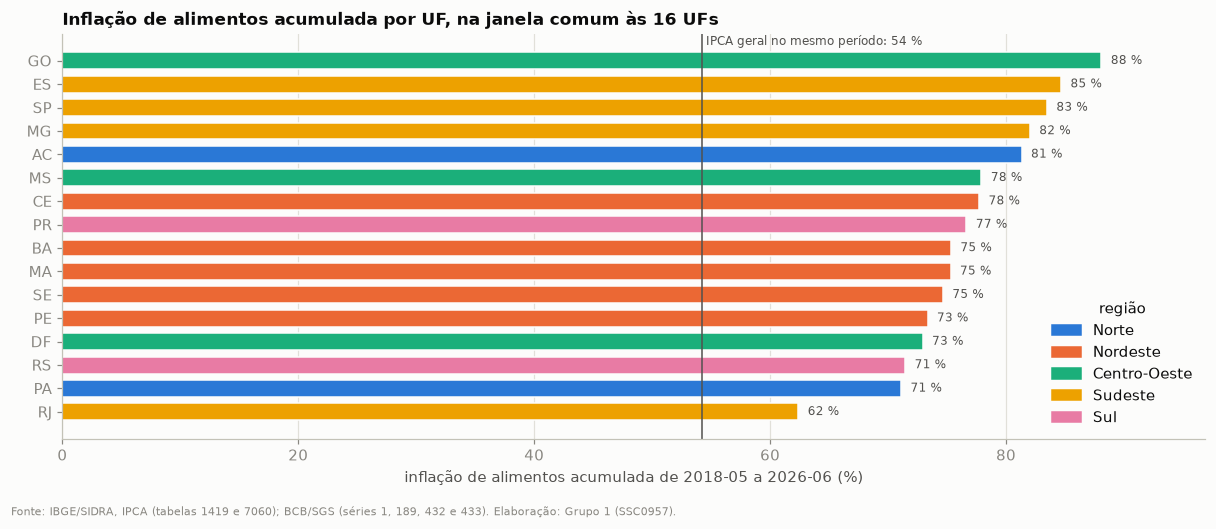

,acum_2018_05_a_2022_05,acum_2022_06_a_2026_06,posicao_1a_metade,posicao_2a_metade,mudou
sigla_uf,,,,,
SP,46.4,25.3,11,1,10
MG,47.2,23.6,9,2,7
DF,40.0,23.5,15,3,12
GO,52.5,23.3,2,4,-2
ES,50.7,22.5,4,5,-1
PE,42.9,21.3,14,6,8
CE,46.6,21.3,10,7,3
PR,47.4,19.8,8,8,0
MS,49.3,19.2,5,9,-4


correlação de Spearman entre as posições nas duas metades: -0.11 (p = 0.68, n = 16)


In [11]:
JANELA = pd.Period("2018-05", "M")
comum = fato[fato["ano_mes"] >= JANELA]


def acumulado(s):
    return (np.prod(1 + s / 100) - 1) * 100


rank = comum.groupby("sigla_uf")["ipca_var_alimentacao"].apply(acumulado).sort_values()
geral_janela = acumulado(nac[nac.index >= JANELA.to_timestamp()])

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.barh(rank.index, rank.values, color=[CORES_REGIAO[REGIAO_DA_UF[u]] for u in rank.index],
        height=0.72, edgecolor=FUNDO, linewidth=1)
for uf, v in rank.items():
    ax.text(v + 0.8, uf, f"{v:.0f} %", va="center", fontsize=8, color=TINTA_2)
ax.axvline(geral_janela, color=TINTA_2, linewidth=1)
ax.text(geral_janela, len(rank) - 0.45, f" IPCA geral no mesmo período: {geral_janela:.0f} %",
        fontsize=8, color=TINTA_2, va="bottom")
ax.set_xlim(0, rank.max() * 1.1)
ax.set_xlabel("inflação de alimentos acumulada de 2018-05 a 2026-06 (%)")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=CORES_REGIAO[r], label=r) for r in REGIOES], loc="lower right", title="região")
ax.set_title("Inflação de alimentos acumulada por UF, na janela comum às 16 UFs")
plt.tight_layout()
salvar(fig, "07_ranking_acumulado_uf", "ipca", "macro")
plt.show()

# O ranking é estável? Duas metades da janela comum.
P1 = (pd.Period("2018-05", "M"), pd.Period("2022-05", "M"))
P2 = (pd.Period("2022-06", "M"), pd.Period("2026-06", "M"))
metades = pd.DataFrame({
    "acum_2018_05_a_2022_05": comum[comum["ano_mes"].between(*P1)].groupby("sigla_uf")["ipca_var_alimentacao"].apply(acumulado),
    "acum_2022_06_a_2026_06": comum[comum["ano_mes"].between(*P2)].groupby("sigla_uf")["ipca_var_alimentacao"].apply(acumulado),
})
metades["posicao_1a_metade"] = metades.iloc[:, 0].rank(ascending=False).astype(int)
metades["posicao_2a_metade"] = metades.iloc[:, 1].rank(ascending=False).astype(int)
metades["mudou"] = metades["posicao_1a_metade"] - metades["posicao_2a_metade"]
display(metades.sort_values("posicao_2a_metade").round(1))
rho_rank = stats.spearmanr(metades["posicao_1a_metade"], metades["posicao_2a_metade"])
print(f"correlação de Spearman entre as posições nas duas metades: {rho_rank.statistic:.2f} (p = {rho_rank.pvalue:.2f}, n = 16)")

**Leitura:** na janela comum (2018-05 a 2026-06), a inflação de alimentos acumulada vai de **62 % (RJ) a
88 % (GO)**, e todas as UFs ficam bem acima do IPCA geral no mesmo período (54 %).

Não há padrão regional limpo: o Sudeste tem a 2ª, a 3ª e a 4ª maiores (ES, SP, MG) e também a menor (RJ).
E o ranking **não é estável**: a correlação entre as posições na 1ª e na 2ª metade da janela é −0,11
(p = 0,68). SP foi de 11º para 1º, e MA de 3º para 16º. Ou seja, a diferença entre UFs existe, mas muda
de lugar com o tempo; não é uma característica fixa da UF. Isso combina com o 0,1 % de variância
explicada pela UF visto em 2.3.

### 2.6 O mapa UF × mês ⭐

O heatmap do T-030: cada linha é uma UF (agrupadas por região), cada coluna um mês, e a cor é a inflação
de alimentos acumulada em 12 meses. **Vermelho** é inflação, **azul** é deflação, e o **cinza** do meio é
zero. A escala é simétrica, para o azul e o vermelho terem o mesmo peso visual.

figura salva: outputs/figuras/eda_08_heatmap_uf_mes.png


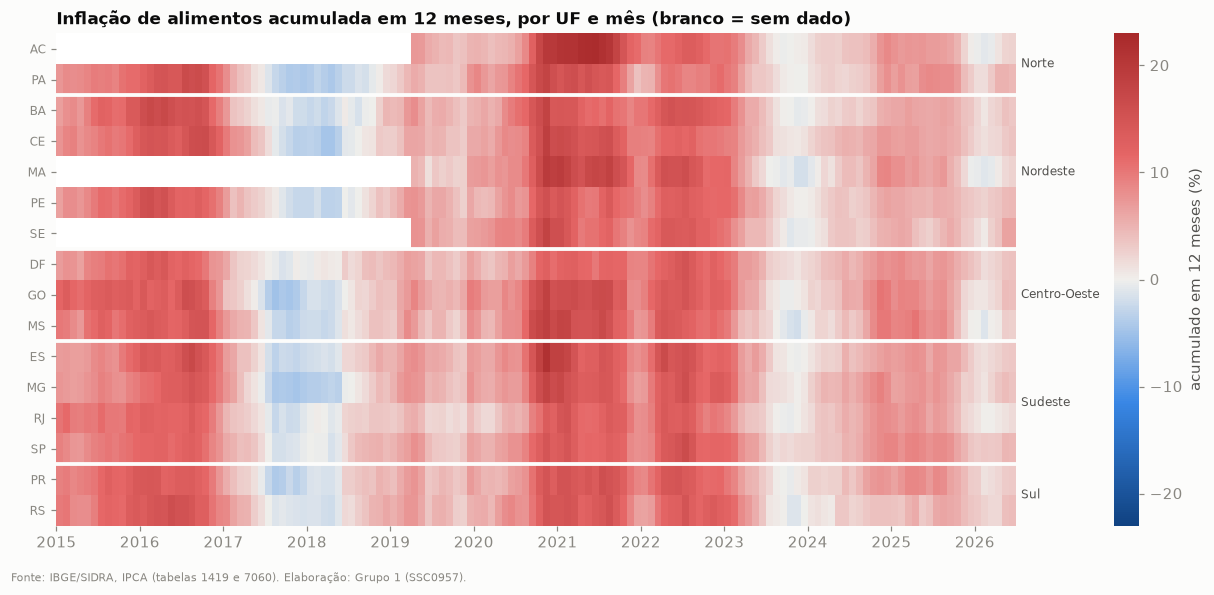

In [12]:
mat = grade["ipca_var_alimentacao_acum12"].unstack("ano_mes").loc[ORDEM_UF]
lim = np.ceil(np.nanmax(np.abs(mat.values)))

fig, ax = plt.subplots(figsize=(11, 5.2))
im = ax.imshow(mat.values, aspect="auto", interpolation="nearest", cmap=DIVERGENTE, vmin=-lim, vmax=lim,
               extent=[x0, x1, len(ORDEM_UF), 0])
ax.xaxis_date()
eixo_tempo(ax, passo=1)
ax.set_yticks(np.arange(len(ORDEM_UF)) + 0.5, ORDEM_UF, fontsize=8)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
# Separadores (linha da cor do fundo) e nome da região à direita.
inicio = 0
for reg in REGIOES:
    n = sum(REGIAO_DA_UF[u] == reg for u in ORDEM_UF)
    if inicio:
        ax.axhline(inicio, color=FUNDO, linewidth=2.5)
    ax.text(1.005, 1 - (inicio + n / 2) / len(ORDEM_UF), reg, transform=ax.transAxes,
            va="center", ha="left", fontsize=8, color=TINTA_2)
    inicio += n
cb = fig.colorbar(im, ax=ax, pad=0.09, fraction=0.03)
cb.set_label("acumulado em 12 meses (%)")
cb.outline.set_visible(False)
ax.set_title("Inflação de alimentos acumulada em 12 meses, por UF e mês (branco = sem dado)")
plt.tight_layout()
salvar(fig, "08_heatmap_uf_mes", "ipca")
plt.show()

**Leitura:** o mapa confirma que o tempo domina. As **faixas verticais** (meses vermelhos ou azuis em
quase todas as UFs) são muito mais fortes que qualquer faixa horizontal.

- A deflação de 2017-18 é a única fase azul. É mais funda em GO, MG, CE e PA, e quase não aparece no RJ e
  em SP.
- O pico de 2020-21 é mais escuro em AC, MA e ES.

As diferenças regionais existem, mas são **variações de intensidade sobre um ciclo comum**, e não ciclos
diferentes. ⭐ Candidata à apresentação: resume em uma figura o "nacional × regional".

### 2.7 Sazonalidade

Duas leituras complementares:

1. **Perfil por mês do ano:** a variação média de cada mês do calendário, por região. Mostra se existe
   um "mês caro" típico.
2. **Decomposição clássica** (`seasonal_decompose`, multiplicativa, período 12), aplicada a um **índice**
   de preços (base dez/2014 = 100) construído com as variações mensais. A decomposição precisa de um
   nível, não de uma variação. Usamos SP, CE e RS: três regiões diferentes, todas com série completa
   desde 2015.

figura salva: outputs/figuras/eda_09_sazonalidade_por_regiao.png


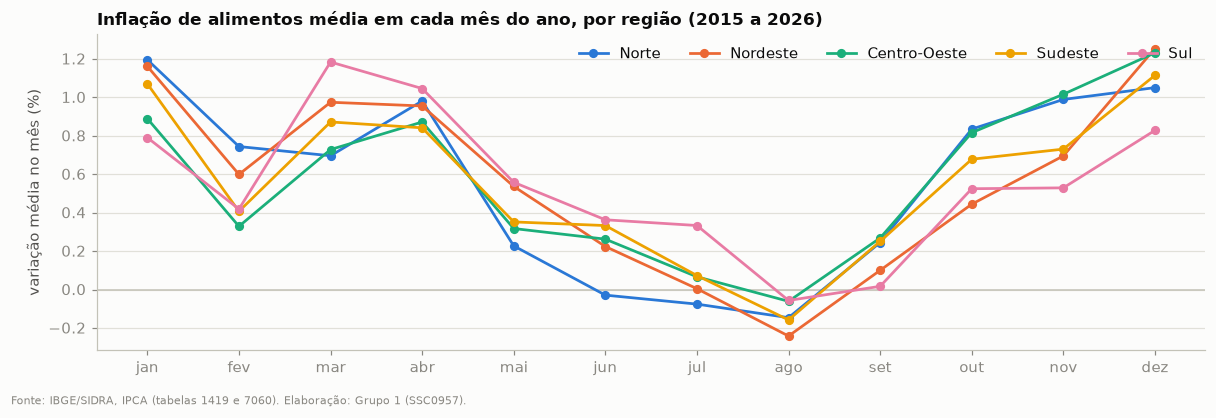

meses mais caros (média nacional): {'dez': 1.13, 'jan': 1.04, 'abr': 0.92}
meses mais baratos (média nacional): {'ago': -0.15, 'jul': 0.07, 'set': 0.18}
Kruskal-Wallis (a distribuição muda com o mês do ano?): H = 391.5, p = 4.0e-77


In [13]:
perfil_mes = fato.groupby(["mes", "regiao"])["ipca_var_alimentacao"].mean().unstack()[REGIOES]

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.axhline(0, color=NEUTRO, linewidth=1)
for reg in REGIOES:
    ax.plot(perfil_mes.index, perfil_mes[reg], color=CORES_REGIAO[reg], marker="o", markersize=5,
            linewidth=1.8, label=reg)
ax.set_xticks(range(1, 13), MESES_ABREV)
ax.grid(axis="x", visible=False)
ax.set_ylabel("variação média no mês (%)")
ax.legend(ncol=5, loc="upper right")
ax.set_title("Inflação de alimentos média em cada mês do ano, por região (2015 a 2026)")
plt.tight_layout()
salvar(fig, "09_sazonalidade_por_regiao", "ipca")
plt.show()

media_mes = fato.groupby("mes")["ipca_var_alimentacao"].mean()
print("meses mais caros (média nacional):", {MESES_ABREV[m - 1]: round(v, 2) for m, v in media_mes.nlargest(3).items()})
print("meses mais baratos (média nacional):", {MESES_ABREV[m - 1]: round(v, 2) for m, v in media_mes.nsmallest(3).items()})
kw = stats.kruskal(*[g.values for _, g in fato.groupby("mes")["ipca_var_alimentacao"]])
print(f"Kruskal-Wallis (a distribuição muda com o mês do ano?): H = {kw.statistic:.1f}, p = {kw.pvalue:.1e}")

figura salva: outputs/figuras/eda_10_decomposicao_sazonal.png


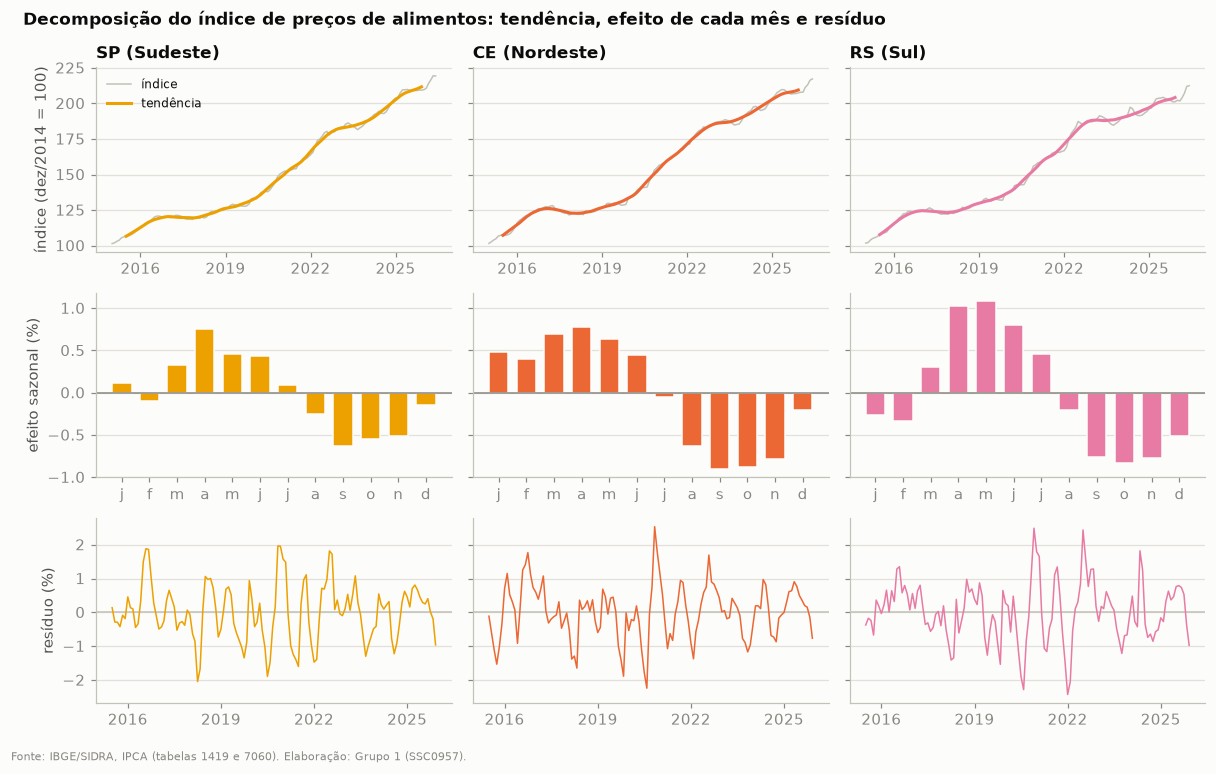

amplitude do efeito sazonal (mês mais caro − mês mais barato, em % do nível): {'SP': np.float64(1.39), 'CE': np.float64(1.68), 'RS': np.float64(1.91)}


In [14]:
UFS_DECOMP = ["SP", "CE", "RS"]
fig, axes = plt.subplots(3, 3, figsize=(11, 6.8), sharey="row")
amplitude = {}
for j, uf in enumerate(UFS_DECOMP):
    s = fato[fato["sigla_uf"] == uf].set_index("data")["ipca_var_alimentacao"]
    indice = 100 * (1 + s / 100).cumprod()
    dec = seasonal_decompose(indice, model="multiplicative", period=12)
    saz = (dec.seasonal.groupby(dec.seasonal.index.month).first() - 1) * 100
    amplitude[uf] = saz.max() - saz.min()
    cor = CORES_REGIAO[REGIAO_DA_UF[uf]]

    axes[0, j].plot(indice.index, indice, color=NEUTRO, linewidth=1, label="índice")
    axes[0, j].plot(dec.trend.index, dec.trend, color=cor, label="tendência")
    axes[0, j].set_title(f"{uf} ({REGIAO_DA_UF[uf]})")
    eixo_tempo(axes[0, j], passo=3)
    axes[1, j].bar(saz.index, saz.values, color=cor, width=0.7, edgecolor=FUNDO, linewidth=1)
    axes[1, j].axhline(0, color=TINTA_3, linewidth=1)
    axes[1, j].set_xticks(range(1, 13), [m[0] for m in MESES_ABREV])
    axes[1, j].grid(axis="x", visible=False)
    axes[2, j].axhline(0, color=NEUTRO, linewidth=1)
    axes[2, j].plot(dec.resid.index, (dec.resid - 1) * 100, color=cor, linewidth=1)
    eixo_tempo(axes[2, j], passo=3)
axes[0, 0].set_ylabel("índice (dez/2014 = 100)")
axes[1, 0].set_ylabel("efeito sazonal (%)")
axes[2, 0].set_ylabel("resíduo (%)")
axes[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Decomposição do índice de preços de alimentos: tendência, efeito de cada mês e resíduo",
             x=0.01, ha="left", fontweight="bold", fontsize=11)
plt.tight_layout()
salvar(fig, "10_decomposicao_sazonal", "ipca")
plt.show()
print("amplitude do efeito sazonal (mês mais caro − mês mais barato, em % do nível):",
      {uf: round(a, 2) for uf, a in amplitude.items()})

**Leitura:** há sazonalidade clara, e o teste de Kruskal-Wallis a confirma com folga (p ≈ 10⁻⁷⁷).

- **Na variação mensal:** a comida sobe mais em dez-jan (1,1 % e 1,0 % em média) e em mar-abr, e sobe
  pouco ou cai em jul-set. Agosto é o único mês com média negativa (−0,15 %).
- **Entre regiões:** o desenho do ano é o mesmo nas cinco, mudando só a amplitude.
- **Na decomposição:** em nível, os preços ficam acima da tendência de março a junho e abaixo de agosto a
  novembro. A distância entre o mês mais caro e o mais barato vai de 1,4 % do nível (SP) a 1,9 % (RS):
  é pouco perto da tendência, mas é sistemático. O resíduo concentra os choques (2016, 2019-12, 2020-22).

**Consequência para o modelo:** o mês do ano precisa entrar como variável (ou o alvo precisa ser
dessazonalizado). Sem isso, a chuva, que também é sazonal, pode levar o crédito da sazonalidade.

### 2.8 As UFs estão ficando parecidas? ⭐

A **dispersão geográfica** é o desvio-padrão entre as UFs, mês a mês. Se ela cai, as UFs convergem (os
preços se movem juntos, como num mercado nacional integrado); se sobe, divergem (os choques são mais
locais). Até 2019-04 o cálculo tem 13 UFs, porque AC, MA e SE ainda não tinham 12 meses de dado.

figura salva: outputs/figuras/eda_11_dispersao_entre_ufs.png


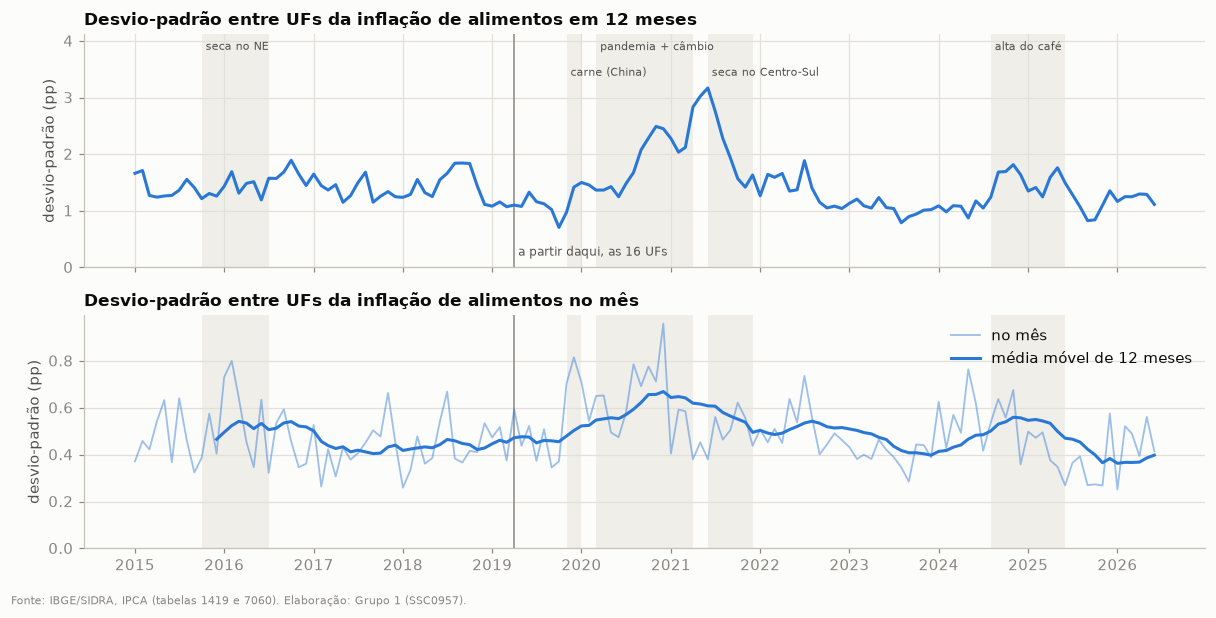

tendência do desvio-padrão em 12 meses desde 2019-04: -0.072 pp/ano (p = 0.006)
tendência do desvio-padrão no mês desde 2019-04: -0.025 pp/ano (p = 0.000)
correlação entre o nível da inflação (média em 12m) e a dispersão: 0.71 (Spearman)


In [15]:
disp = fato.groupby("data").agg(
    dp_acum12=("ipca_var_alimentacao_acum12", "std"),
    dp_mes=("ipca_var_alimentacao", "std"),
    media_acum12=("ipca_var_alimentacao_acum12", "mean"),
    n_ufs=("ipca_var_alimentacao_acum12", "count"),
)
disp["cv_acum12"] = disp["dp_acum12"] / disp["media_acum12"].abs()
todas = disp.index[disp["n_ufs"] == 16][0]

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)
for ax in (a1, a2):
    marcar_eventos(ax, rotulos=ax is a1)
    ax.axvline(todas, color=TINTA_3, linewidth=1)
a1.plot(disp.index, disp["dp_acum12"], color=CORES["ipca"])
a1.text(todas, 0.05, " a partir daqui, as 16 UFs", transform=a1.get_xaxis_transform(), fontsize=8, color=TINTA_2)
a1.set_ylabel("desvio-padrão (pp)")
a1.set_title("Desvio-padrão entre UFs da inflação de alimentos em 12 meses")
a1.set_ylim(0, disp["dp_acum12"].max() * 1.3)
a2.plot(disp.index, disp["dp_mes"], color=CORES["ipca"], linewidth=1.2, alpha=0.45, label="no mês")
a2.plot(disp.index, disp["dp_mes"].rolling(12).mean(), color=CORES["ipca"], label="média móvel de 12 meses")
a2.set_ylabel("desvio-padrão (pp)")
a2.set_title("Desvio-padrão entre UFs da inflação de alimentos no mês")
a2.set_ylim(bottom=0)
a2.legend(loc="upper right")
eixo_tempo(a2, passo=1)
plt.tight_layout()
salvar(fig, "11_dispersao_entre_ufs", "ipca")
plt.show()

d = disp.loc[todas:].dropna()
anos = (d.index - d.index[0]).days / 365.25
for col, nome in [("dp_acum12", "desvio-padrão em 12 meses"), ("dp_mes", "desvio-padrão no mês")]:
    reg = stats.linregress(anos, d[col])
    print(f"tendência do {nome} desde {todas:%Y-%m}: {reg.slope:+.3f} pp/ano (p = {reg.pvalue:.3f})")
print(f"correlação entre o nível da inflação (média em 12m) e a dispersão: "
      f"{stats.spearmanr(d['media_acum12'], d['dp_acum12']).statistic:.2f} (Spearman)")

**Leitura:** desde 2019-04, com as 16 UFs, a dispersão **caiu um pouco**: −0,07 pp por ano no acumulado
em 12 meses (p = 0,006) e −0,025 pp por ano no mês. Há uma leve convergência.

O movimento mais visível, porém, não é a tendência, e sim os **picos**. A dispersão sobe junto com a
inflação (Spearman de 0,71 entre o nível e a dispersão) e chegou a ~3,1 pp em meados de 2021. **Em choque,
as UFs divergem; na calma, andam juntas.** É aí que está a "volatilidade regional" da pergunta central:
nos episódios de choque, não no nível médio. ⭐ Candidata à apresentação.

---
## Parte 3: os itens dentro da comida

A tabela traz, além do grupo Alimentação, 16 colunas de itens do IPCA. **Atenção:** elas misturam três
níveis da hierarquia do IBGE (grupo, subgrupo e subitem); por exemplo, *Frango inteiro* está dentro de
*Aves e ovos*. Por isso as colunas servem para comparar lado a lado e **nunca podem ser somadas**.

figura salva: outputs/figuras/eda_12_volatilidade_itens.png


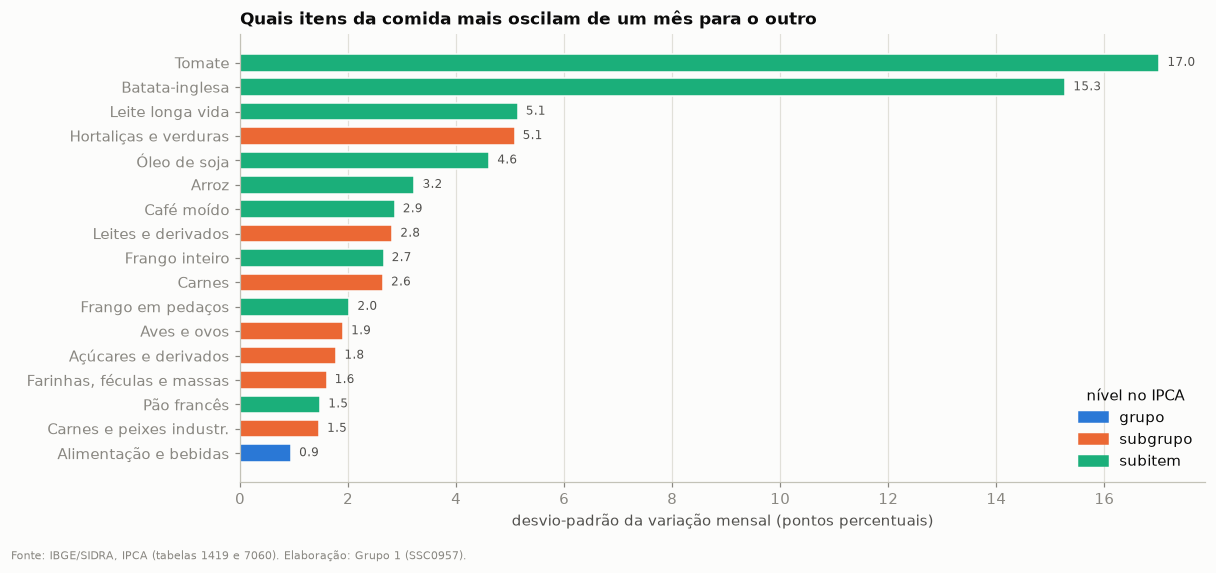

,nivel,desvio_padrao_pp,media_pct,minimo_pct,maximo_pct,meses_negativos_pct
tomate,subitem,17.02,2.28,-44.86,89.11,48.61
batata_inglesa,subitem,15.28,1.94,-40.96,77.04,49.52
leite_longa_vida,subitem,5.14,0.72,-20.84,32.25,48.37
hortalicas,subgrupo,5.08,0.80,-18.12,35.23,44.01
oleo_soja,subitem,4.61,0.80,-13.49,39.33,45.26
arroz,subitem,3.23,0.48,-8.15,41.94,48.80
cafe_moido,subitem,2.86,0.94,-6.40,18.92,42.24
leites_derivados,subgrupo,2.82,0.60,-13.29,19.23,43.73
frango_inteiro,subitem,2.66,0.56,-8.98,19.68,42.00
carnes,subgrupo,2.65,0.67,-8.48,22.49,42.43


In [16]:
NOMES = {
    "alimentacao": "Alimentação e bebidas", "arroz": "Arroz", "farinhas": "Farinhas, féculas e massas",
    "batata_inglesa": "Batata-inglesa", "tomate": "Tomate", "acucares": "Açúcares e derivados",
    "hortalicas": "Hortaliças e verduras", "carnes": "Carnes", "carnes_industrializadas": "Carnes e peixes industr.",
    "aves_ovos": "Aves e ovos", "frango_inteiro": "Frango inteiro", "frango_pedacos": "Frango em pedaços",
    "leites_derivados": "Leites e derivados", "leite_longa_vida": "Leite longa vida", "pao_frances": "Pão francês",
    "oleo_soja": "Óleo de soja", "cafe_moido": "Café moído",
}
SUBGRUPOS = {"farinhas", "acucares", "hortalicas", "carnes", "carnes_industrializadas", "aves_ovos", "leites_derivados"}
NIVEL = {i: "grupo" if i == "alimentacao" else "subgrupo" if i in SUBGRUPOS else "subitem" for i in NOMES}
CORES_NIVEL = {"grupo": "#2a78d6", "subgrupo": "#eb6834", "subitem": "#1baf7a"}

itens = fato[[f"ipca_var_{i}" for i in NOMES]].rename(columns=lambda c: c.removeprefix("ipca_var_"))
tab_itens = pd.DataFrame({
    "nivel": pd.Series(NIVEL),
    "desvio_padrao_pp": itens.std(),
    "media_pct": itens.mean(),
    "minimo_pct": itens.min(),
    "maximo_pct": itens.max(),
    "meses_negativos_pct": (itens < 0).mean() * 100,
}).sort_values("desvio_padrao_pp")

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh([NOMES[i] for i in tab_itens.index], tab_itens["desvio_padrao_pp"],
        color=[CORES_NIVEL[n] for n in tab_itens["nivel"]], height=0.72, edgecolor=FUNDO, linewidth=1)
for k, (i, v) in enumerate(tab_itens["desvio_padrao_pp"].items()):
    ax.text(v + 0.15, k, f"{v:.1f}", va="center", fontsize=8, color=TINTA_2)
ax.set_xlabel("desvio-padrão da variação mensal (pontos percentuais)")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=c, label=n) for n, c in CORES_NIVEL.items()], loc="lower right",
          title="nível no IPCA")
ax.set_title("Quais itens da comida mais oscilam de um mês para o outro")
plt.tight_layout()
salvar(fig, "12_volatilidade_itens", "ipca")
plt.show()
display(tab_itens.sort_values("desvio_padrao_pp", ascending=False).round(2))

figura salva: outputs/figuras/eda_13_cafe_tomate_vs_alimentacao.png


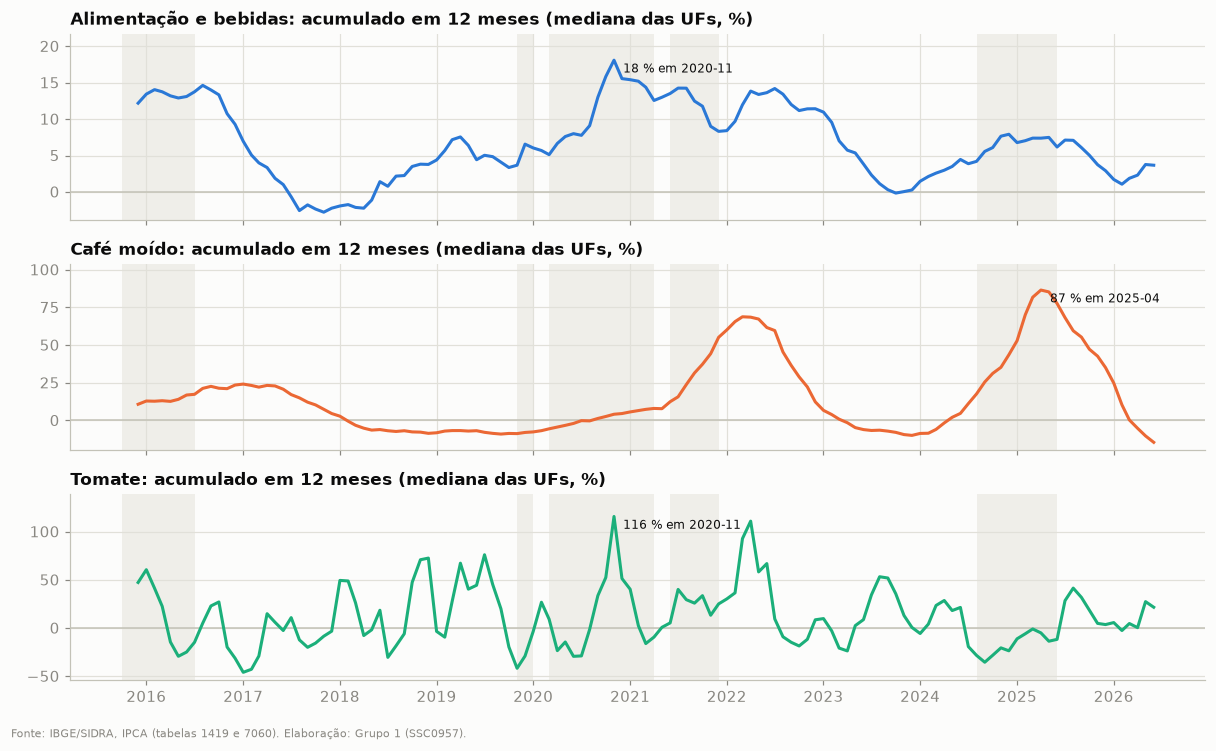

In [17]:
def acum12_por_uf(col):
    return fato.groupby("sigla_uf")[col].transform(acum12)


SERIES = [("alimentacao", CORES["ipca"]), ("cafe_moido", CORES_REGIAO["Nordeste"]), ("tomate", CORES_REGIAO["Centro-Oeste"])]
fig, axes = plt.subplots(3, 1, figsize=(11, 6.6), sharex=True)
for ax, (item, cor) in zip(axes, SERIES):
    med = acum12_por_uf(f"ipca_var_{item}").groupby(fato["data"]).median()
    marcar_eventos(ax, rotulos=False)
    ax.axhline(0, color=NEUTRO, linewidth=1)
    ax.plot(med.index, med, color=cor)
    ax.set_ylim(top=med.max() * 1.2)
    ax.set_title(f"{NOMES[item]}: acumulado em 12 meses (mediana das UFs, %)")
    pico = med.idxmax()
    ax.annotate(f"{med.max():.0f} % em {pico:%Y-%m}", (pico, med.max()), xytext=(6, -2),
                textcoords="offset points", fontsize=8, color=TINTA, va="top")
eixo_tempo(axes[-1], passo=1)
plt.tight_layout()
salvar(fig, "13_cafe_tomate_vs_alimentacao", "ipca")
plt.show()

**Leitura:** os itens oscilam muito mais que o grupo.

- **Tomate e batata-inglesa** (desvio de 17 pp e 15 pp por mês) são produtos de ciclo curto e perecíveis.
  Sobem ou caem em metade dos meses (48-50 % de meses negativos), e o tomate acumulou 116 % em 12 meses em
  2020-11.
- **O grupo Alimentação**, com desvio de só 0,94 pp, mostra que os itens se compensam entre si.
- **O café** tem outro ritmo, de safra perene: o acumulado em 12 meses chegou a 69 % em 2022 e a **87 % em
  2025-04**, e essa é uma das razões da alta do grupo em 2024-25.

Isso indica **onde procurar o clima**: o choque climático deve aparecer rápido em tomate, batata e
hortaliças, e devagar no café. Analisar só o grupo dilui esse sinal.

---
## Parte 4: os fatores, família por família

Cada família tem **um recorte obrigatório** antes de ser usada; ele foi decidido na junção e está no
dicionário. Esta parte mostra o comportamento de cada uma já com o recorte certo.

### 4.1 Clima (INMET)

Valores por UF = **mediana** das estações da UF. A primeira figura mostra a sazonalidade física; a
segunda (⭐) é a que introduz a hipótese do trabalho: **a sazonalidade da chuva e a do preço andam juntas?**

figura salva: outputs/figuras/eda_14_clima_sazonalidade.png


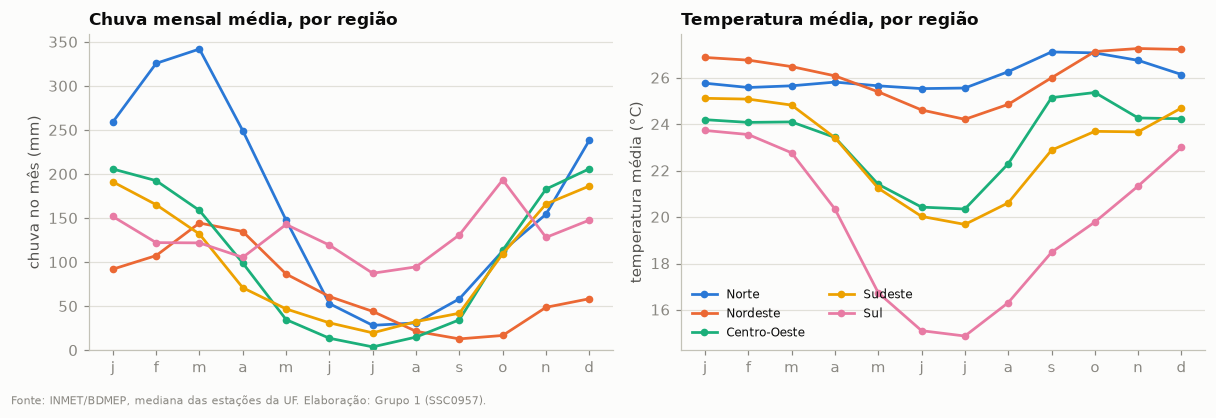

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, rot in [(a1, "clima_chuva_mm_mes", "chuva no mês (mm)"), (a2, "clima_temp_media", "temperatura média (°C)")]:
    prof = fato.groupby(["mes", "regiao"])[col].mean().unstack()[REGIOES]
    for reg in REGIOES:
        ax.plot(prof.index, prof[reg], color=CORES_REGIAO[reg], marker="o", markersize=4, linewidth=1.8, label=reg)
    ax.set_xticks(range(1, 13), [m[0] for m in MESES_ABREV])
    ax.grid(axis="x", visible=False)
    ax.set_ylabel(rot)
a1.set_title("Chuva mensal média, por região")
a1.set_ylim(bottom=0)
a2.set_title("Temperatura média, por região")
a2.legend(loc="lower left", ncol=2, fontsize=8)
plt.tight_layout()
salvar(fig, "14_clima_sazonalidade", "clima")
plt.show()

figura salva: outputs/figuras/eda_15_sazonalidade_chuva_vs_preco.png


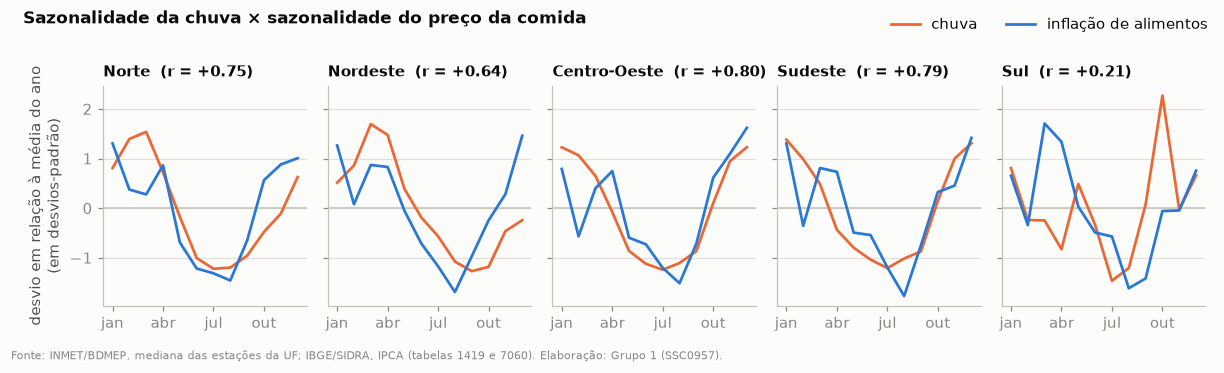

In [19]:
# Os dois perfis em desvios-padrão (z-score do perfil de 12 meses): mesma escala, um só eixo.
def z12(s):
    return (s - s.mean()) / s.std()


fig, axes = plt.subplots(1, 5, figsize=(11, 3.0), sharey=True)
corr_saz = {}
for ax, reg in zip(axes, REGIOES):
    sub = fato[fato["regiao"] == reg]
    chuva = z12(sub.groupby("mes")["clima_chuva_mm_mes"].mean())
    preco = z12(sub.groupby("mes")["ipca_var_alimentacao"].mean())
    corr_saz[reg] = np.corrcoef(chuva, preco)[0, 1]
    ax.axhline(0, color=NEUTRO, linewidth=1)
    ax.plot(chuva.index, chuva, color=CORES["clima"], linewidth=1.8, label="chuva")
    ax.plot(preco.index, preco, color=CORES["ipca"], linewidth=1.8, label="inflação de alimentos")
    ax.set_xticks([1, 4, 7, 10], ["jan", "abr", "jul", "out"])
    ax.grid(axis="x", visible=False)
    ax.set_title(f"{reg}  (r = {corr_saz[reg]:+.2f})", fontsize=9.5)
axes[0].set_ylabel("desvio em relação à média do ano\n(em desvios-padrão)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, bbox_to_anchor=(1.0, 1.04))
fig.suptitle("Sazonalidade da chuva × sazonalidade do preço da comida", x=0.01, ha="left",
             fontweight="bold", fontsize=11, y=1.02)
plt.tight_layout()
salvar(fig, "15_sazonalidade_chuva_vs_preco", "clima", "ipca")
plt.show()

estações por UF (mín → máx no período): {'AC': '1→6', 'PA': '6→28', 'BA': '10→48', 'CE': '1→16', 'MA': '1→15', 'PE': '2→13', 'SE': '0→7', 'DF': '3→5', 'GO': '13→26', 'MS': '3→39', 'ES': '6→13', 'MG': '42→66', 'RJ': '13→26', 'SP': '13→41', 'PR': '7→25', 'RS': '26→77'}


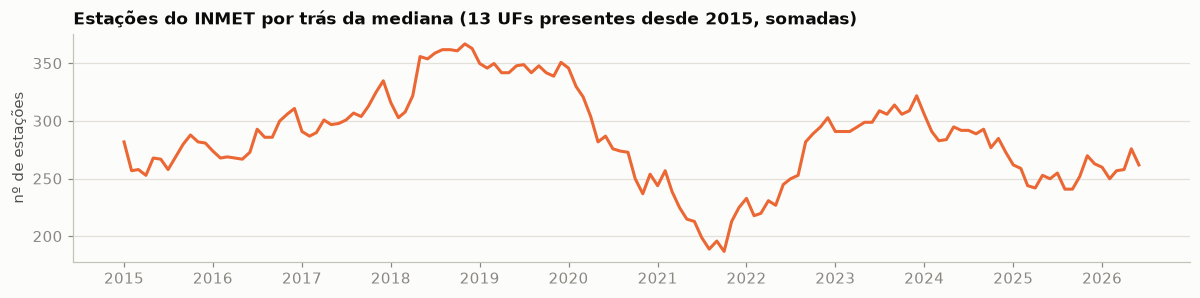

In [20]:
n_est = fato.pivot(index="data", columns="sigla_uf", values="clima_n_estacoes")
print("estações por UF (mín → máx no período):",
      {uf: f"{int(n_est[uf].min())}→{int(n_est[uf].max())}" for uf in ORDEM_UF})

fig, ax = plt.subplots(figsize=(11, 2.8))
total = n_est[[u for u in ORDEM_UF if u not in ("AC", "MA", "SE")]].sum(axis=1)
ax.plot(total.index, total, color=CORES["clima"])
ax.set_ylabel("nº de estações")
ax.set_title("Estações do INMET por trás da mediana (13 UFs presentes desde 2015, somadas)")
eixo_tempo(ax, passo=1)
plt.tight_layout()
plt.show()

**Leitura:** a sazonalidade física está como esperado, o que confirma que a agregação por mediana não
destruiu o sinal.

- **Norte, Centro-Oeste e Sudeste:** estação chuvosa de outubro a março e seca de junho a agosto.
- **Nordeste:** chuva concentrada em mar-abr (estação chuvosa do semiárido e do litoral norte).
- **Sul:** chuva distribuída o ano inteiro, e o inverno mais frio (~15 °C).

O gráfico ⭐ de chuva × preço mostra que, no Norte, Nordeste, Centro-Oeste e Sudeste, **os meses chuvosos
são os de comida mais cara** (r de +0,64 a +0,80). No Sul, onde a chuva não é sazonal, a relação some
(+0,21). **Cautela:** são 12 pontos (perfis médios), e as duas sazonalidades podem ter causas
independentes, como entressafra e festas de fim de ano. É uma coincidência de calendário que motiva a
hipótese, não uma prova; o T-031 testa com defasagem.

A rede de estações cresce muito em algumas UFs: SE foi de 0 a 7 estações, CE de 1 a 16, MS de 3 a 39. Um
degrau no nível do clima de uma UF pode ser artefato da rede, e por isso `clima_n_estacoes` fica na tabela.

### 4.2 Safra (IBGE/LSPA)

O sinal útil da safra não é a produção (que é a **estimativa da safra do ano inteiro**, não um fluxo
mensal), e sim a **revisão %** dessa estimativa de um mês para o outro: é ali que aparece a notícia de
quebra ou de supersafra. Três cuidados:

- a revisão é `NaN` **em todo janeiro**, por construção (não há mês anterior dentro da mesma safra);
- `NaN` também quer dizer "a UF não planta isso", e não dado faltante;
- a cauda é explosiva (divisão por base minúscula), por isso a junção já **winsorizou a coluna em ±50 %**
  (`src/tratamento/24_junta.py`). Valores exatamente em ±50 são revisões que estouraram o teto.

,nulos_pct,meses_com_revisao_pct,no_teto_de_±50_pct,revisao_abs_mediana_quando_revisa,maior_revisao_abs
batata_inglesa,49.5,34.8,1.0,1.6,50.0
cafe,23.3,39.3,0.6,1.8,50.0
trigo,52.7,40.7,1.5,5.0,50.0
arroz,15.6,42.2,1.0,1.4,50.0
tomate,17.0,42.9,0.9,1.4,50.0
banana,12.0,44.1,0.3,0.7,50.0
cana_de_acucar,9.1,45.0,0.2,0.5,50.0
soja,32.5,46.1,0.4,0.8,50.0
mandioca,8.6,48.0,0.1,0.8,50.0
feijao,8.6,54.0,0.7,2.3,50.0


figura salva: outputs/figuras/eda_16_safra_revisoes.png


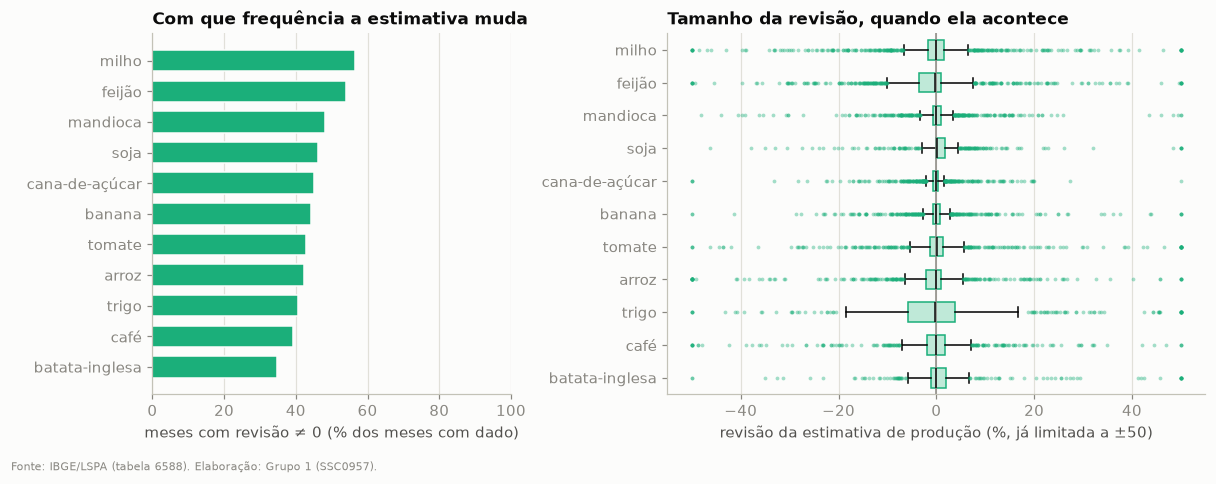

In [21]:
PRODUTOS = [c.removeprefix("safra_revisao_pct_") for c in fato.columns if c.startswith("safra_revisao_pct_")]
rev = fato[[f"safra_revisao_pct_{p}" for p in PRODUTOS]].rename(columns=lambda c: c.removeprefix("safra_revisao_pct_"))
validos = rev.notna().sum()
tab_safra = pd.DataFrame({
    "nulos_pct": rev.isna().mean() * 100,
    "meses_com_revisao_pct": (rev.fillna(0) != 0).sum() / validos * 100,
    "no_teto_de_±50_pct": (rev.abs() >= 50).sum() / validos * 100,
    "revisao_abs_mediana_quando_revisa": rev[rev != 0].abs().median(),
    "maior_revisao_abs": rev.abs().max(),
}).sort_values("meses_com_revisao_pct")
display(tab_safra.round(1))

rev_w = rev  # já vem winsorizada em ±50 % da junção (src/tratamento/24_junta.py)
ROTULO_PRODUTO = {"batata_inglesa": "batata-inglesa", "cafe": "café", "cana_de_acucar": "cana-de-açúcar",
                  "feijao": "feijão"}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1, 1.5]})
ordem = tab_safra.index
a1.barh([ROTULO_PRODUTO.get(p, p) for p in ordem], tab_safra["meses_com_revisao_pct"], color=CORES["safra"], height=0.7, edgecolor=FUNDO)
a1.set_xlim(0, 100)
a1.set_xlabel("meses com revisão ≠ 0 (% dos meses com dado)")
a1.grid(axis="y", visible=False)
a1.set_title("Com que frequência a estimativa muda")
dados = [rev_w[p][rev_w[p].fillna(0) != 0].values for p in ordem]
bp = a2.boxplot(dados, orientation="horizontal", tick_labels=[ROTULO_PRODUTO.get(p, p) for p in ordem], patch_artist=True, widths=0.6,
                medianprops={"color": TINTA}, flierprops={"marker": "o", "markersize": 2.5,
                                                         "markerfacecolor": CORES["safra"], "markeredgewidth": 0, "alpha": 0.4})
for caixa in bp["boxes"]:
    caixa.set(facecolor="#bfe9d8", edgecolor=CORES["safra"])
a2.axvline(0, color=TINTA_3, linewidth=1)
a2.set_xlabel("revisão da estimativa de produção (%, já limitada a ±50)")
a2.grid(axis="y", visible=False)
a2.set_title("Tamanho da revisão, quando ela acontece")
plt.tight_layout()
salvar(fig, "16_safra_revisoes", "safra")
plt.show()

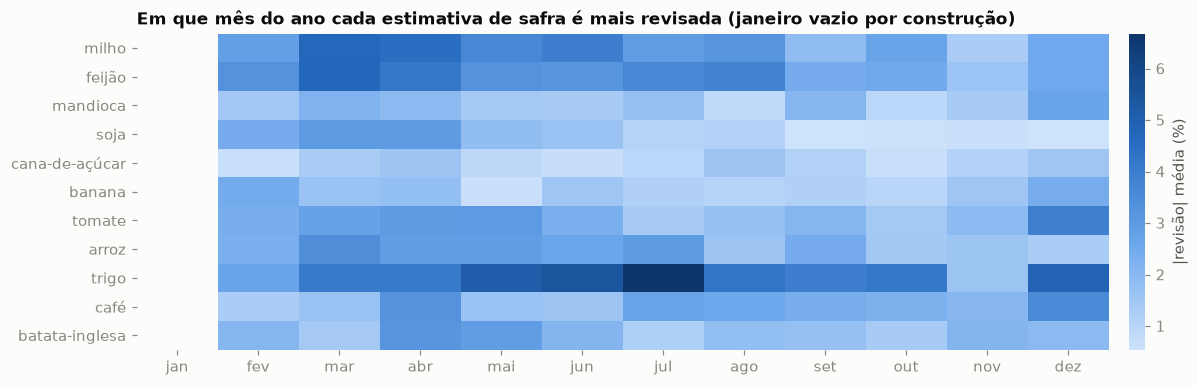

In [22]:
# Em que mês do ano a estimativa costuma ser revisada? (média de |revisão|, winsorizada)
quando = rev_w.abs().groupby(fato["mes"]).mean().T.loc[ordem[::-1]]
fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(quando.values, aspect="auto", cmap=SEQUENCIAL, interpolation="nearest")
ax.set_xticks(range(12), MESES_ABREV)
ax.set_yticks(range(len(quando)), [ROTULO_PRODUTO.get(p, p) for p in quando.index])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("|revisão| média (%)")
cb.outline.set_visible(False)
ax.set_title("Em que mês do ano cada estimativa de safra é mais revisada (janeiro vazio por construção)")
plt.tight_layout()
plt.show()

**Leitura:** a estimativa de safra muda em 35 % a 57 % dos meses (milho e feijão são os mais revisados),
mas quase sempre pouco. A revisão mediana, quando acontece, vai de 0,5 % (cana) a 5 % (trigo). Os valores
no teto de ±50 % são raros (0,1 % a 1,5 %) e vêm de UFs com produção minúscula.

As revisões se concentram em **março e abril**, quando a safra de verão é colhida e medida, e são menores
em outubro e novembro. Na Parte 5, a correlação **no mesmo mês** com o alvo é praticamente zero. Isso é
esperado por dois motivos:

1. a notícia de quebra chega ao preço com defasagem;
2. a revisão da safra **de uma UF** importa pouco para o preço **naquela UF** se a comida vem de outra.

É o argumento do T-022 (safra e clima ponderados pela região produtora).

### 4.3 Seca (ANA, Monitor de Secas)

Só entram aqui as linhas com `seca_monitorado == True`. `NaN` quer dizer "a UF ainda não estava no
programa", **não** "não houve seca". O painel de baixo mostra quantas das 16 UFs já eram monitoradas a
cada mês: é por isso que, ao usar a seca como regressor, a análise começa em **2020-01**.

figura salva: outputs/figuras/eda_17_seca_por_regiao.png


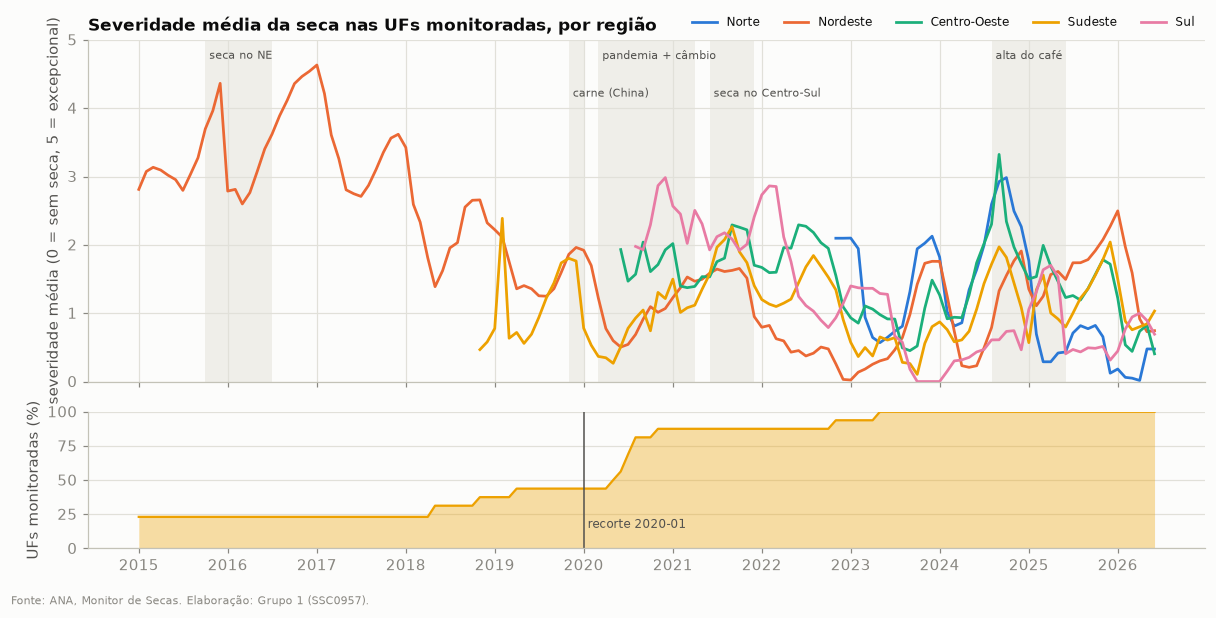

severidade média por região (só UFs monitoradas, 2020-01 em diante):
              mean   max  count
regiao                         
Norte         1.14  3.92     83
Nordeste      1.08  3.39    389
Centro-Oeste  1.50  4.00    217
Sudeste       1.11  3.52    298
Sul           1.24  3.14    142


In [23]:
mon = fato[fato["seca_monitorado"]]
sev = mon.groupby(["data", "regiao"])["seca_severidade_media"].mean().unstack().reindex(columns=REGIOES)
cobertura = fato.groupby("data")["seca_monitorado"].mean() * 100

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True, gridspec_kw={"height_ratios": [3, 1.2]})
marcar_eventos(a1)
for reg in REGIOES:
    a1.plot(sev.index, sev[reg], color=CORES_REGIAO[reg], linewidth=1.8, label=reg)
a1.set_ylabel("severidade média (0 = sem seca, 5 = excepcional)")
a1.set_ylim(0, 5)
a1.legend(ncol=5, loc="lower right", bbox_to_anchor=(1.0, 1.0), fontsize=8)
a1.set_title("Severidade média da seca nas UFs monitoradas, por região")
a2.fill_between(cobertura.index, 0, cobertura, color=CORES["seca"], alpha=0.35, linewidth=0)
a2.plot(cobertura.index, cobertura, color=CORES["seca"], linewidth=1.5)
a2.axvline(pd.Timestamp("2020-01-01"), color=TINTA_2, linewidth=1)
a2.text(pd.Timestamp("2020-01-01"), 15, " recorte 2020-01", fontsize=8, color=TINTA_2)
a2.set_ylim(0, 100)
a2.set_ylabel("UFs monitoradas (%)")
eixo_tempo(a2, passo=1)
plt.tight_layout()
salvar(fig, "17_seca_por_regiao", "seca")
plt.show()

print("severidade média por região (só UFs monitoradas, 2020-01 em diante):")
print(mon[mon["ano_mes"] >= pd.Period("2020-01", "M")].groupby("regiao")["seca_severidade_media"]
      .agg(["mean", "max", "count"]).reindex(REGIOES).round(2).to_string())

**Leitura:** o Nordeste é a única região com série longa, e ela mostra a grande seca de 2015-17, com
severidade média passando de 4 (de 5) no fim de 2015 e de novo entre o fim de 2016 e o início de 2017. Depois de 2020 todas as regiões têm dado, e a
severidade média fica entre 1,1 e 1,5.

- **Centro-Oeste:** a região mais seca do período (1,50 em média) e com o pico de 2024 (3,3), junto com o
  Norte (~3).
- **Sul:** estiagens fortes em 2020-21 e 2022 (~3).

Por causa da entrada escalonada das UFs, comparar regiões antes de 2020 compara grupos de UFs diferentes.
O recorte em 2020-01 é obrigatório para usar a seca como variável.

### 4.4 Macroeconomia (BCB)

Estas colunas são **iguais em todas as UFs** no mesmo mês (broadcast nacional). Elas explicam variação
**no tempo**, nunca diferença **entre UFs**. Basta, então, olhar uma série por variável.

figura salva: outputs/figuras/eda_18_macro.png


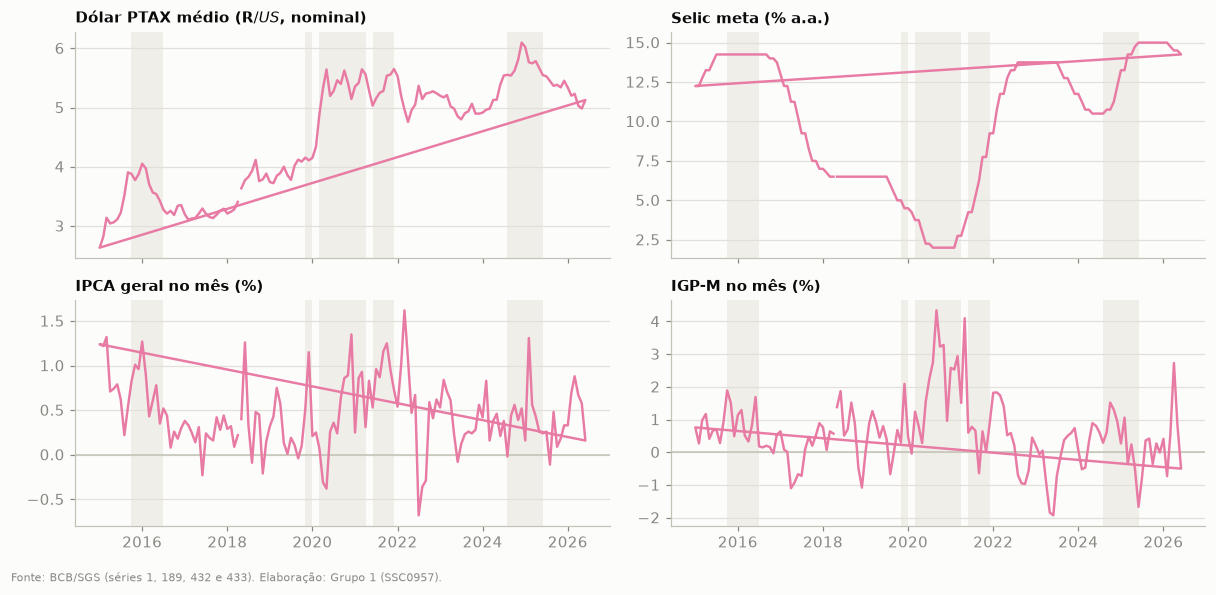

In [24]:
MACRO = [("macro_dolar_ptax_medio", "Dólar PTAX médio (R$/US$, nominal)"),
         ("macro_selic", "Selic meta (% a.a.)"),
         ("macro_ipca_mm", "IPCA geral no mês (%)"),
         ("macro_igpm", "IGP-M no mês (%)")]
macro = fato.drop_duplicates("ano_mes").set_index("data")
fig, axes = plt.subplots(2, 2, figsize=(11, 5.2), sharex=True)
for ax, (col, titulo) in zip(axes.flat, MACRO):
    marcar_eventos(ax, rotulos=False)
    if macro[col].min() < 0:
        ax.axhline(0, color=NEUTRO, linewidth=1)
    ax.plot(macro.index, macro[col], color=CORES["macro"], linewidth=1.6)
    ax.set_title(titulo, fontsize=10)
    eixo_tempo(ax, passo=2)
plt.tight_layout()
salvar(fig, "18_macro", "macro")
plt.show()

**Leitura:** as quatro séries nacionais variaram muito no período:

- **dólar:** de R$ 2,63 (2015-01) a R$ 6,10 (2024-12);
- **Selic:** de 2 % (2020-08) a 15 % (2025-06);
- **IPCA geral no mês:** entre −0,68 % (2022-07) e 1,62 % (2022-03);
- **IGP-M:** pico de 4,34 % em 2020-09.

Todas têm o mesmo ciclo de 2020-22 que o alvo. Por isso a correlação delas com o alvo vai ser, em boa
parte, **correlação de tempo**: ajudam a explicar *quando* a comida sobe, nunca *onde* sobe mais.

### 4.5 Combustíveis (ANP)

O diesel é o custo do **frete**, e o GLP é o custo de **cozinhar** (hipótese H3, logística). Os preços
estão em **R$ correntes** (sem deflacionar), então comparam bem meses próximos, mas não anos distantes.
Os buracos nas linhas são os meses **sem pesquisa da ANP**: não foram interpolados.

figura salva: outputs/figuras/eda_19_combustiveis_precos.png


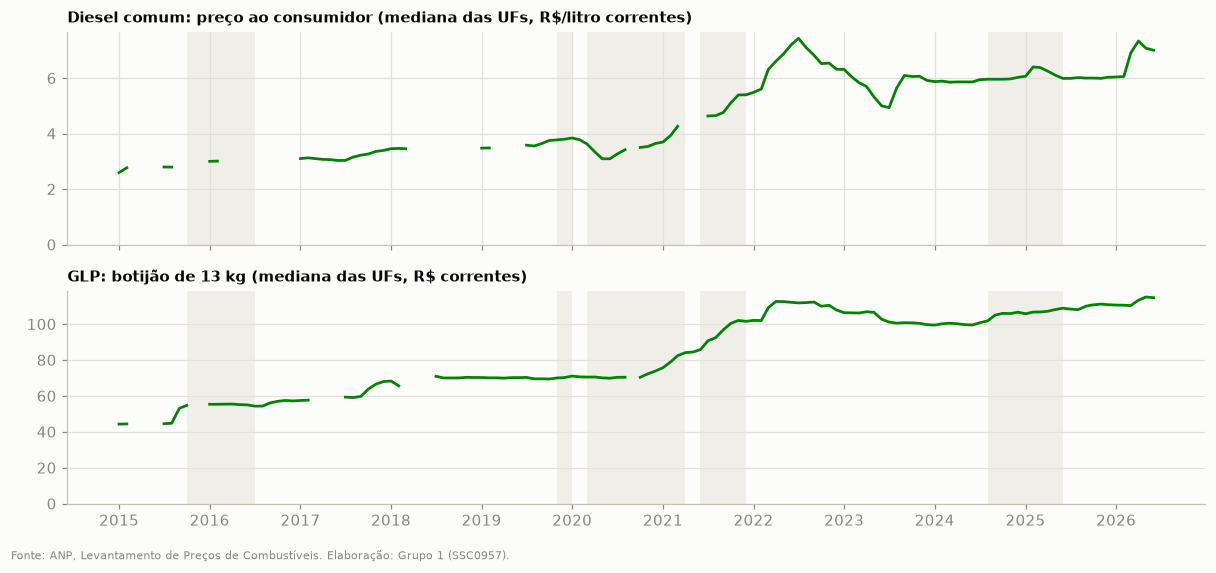

figura salva: outputs/figuras/eda_20_diesel_relativo_por_uf.png


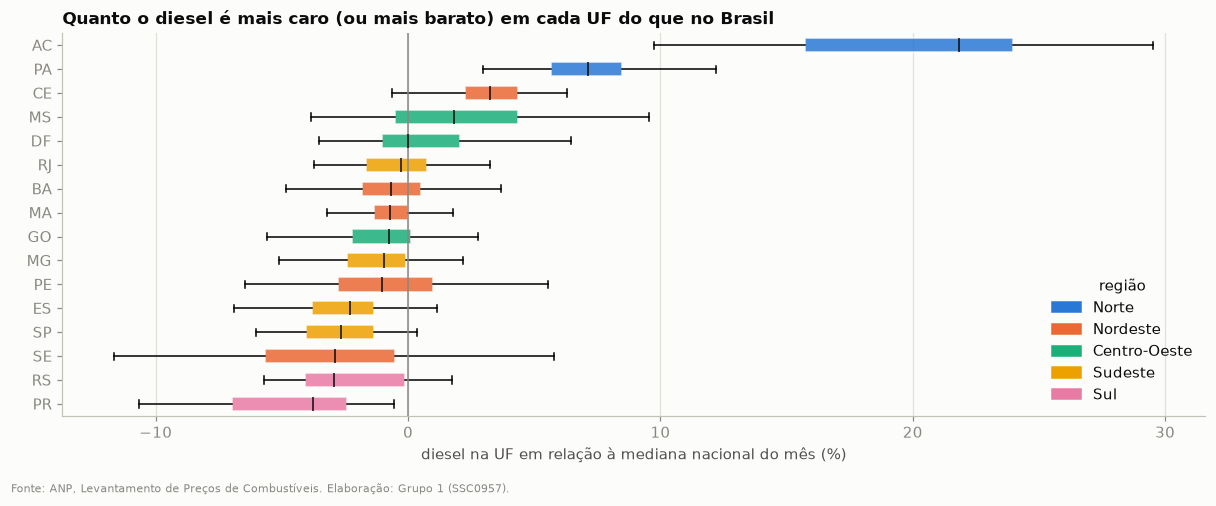

In [25]:
med_comb = fato.groupby("data")[["comb_preco_diesel", "comb_preco_glp_13kg"]].median()
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for ax, col, titulo in [(a1, "comb_preco_diesel", "Diesel comum: preço ao consumidor (mediana das UFs, R$/litro correntes)"),
                        (a2, "comb_preco_glp_13kg", "GLP: botijão de 13 kg (mediana das UFs, R$ correntes)")]:
    marcar_eventos(ax, rotulos=False)
    ax.plot(med_comb.index, med_comb[col], color=CORES["comb"], linewidth=1.8)
    ax.set_title(titulo, fontsize=10)
    ax.set_ylim(bottom=0)
eixo_tempo(a2, passo=1)
plt.tight_layout()
salvar(fig, "19_combustiveis_precos", "comb")
plt.show()

dv = fato[fato["comb_observado_liquidos"]]
ordem_uf = dv.groupby("sigla_uf")["comb_diesel_vs_br_pct"].median().sort_values().index
fig, ax = plt.subplots(figsize=(11, 4.4))
bp = ax.boxplot([dv.loc[dv["sigla_uf"] == u, "comb_diesel_vs_br_pct"].dropna() for u in ordem_uf],
                orientation="horizontal", tick_labels=list(ordem_uf), patch_artist=True, widths=0.6,
                medianprops={"color": TINTA}, flierprops={"marker": "o", "markersize": 2.5, "markeredgewidth": 0})
for caixa, uf in zip(bp["boxes"], ordem_uf):
    caixa.set(facecolor=CORES_REGIAO[REGIAO_DA_UF[uf]], edgecolor=FUNDO, alpha=0.85)
ax.axvline(0, color=TINTA_3, linewidth=1)
ax.set_xlabel("diesel na UF em relação à mediana nacional do mês (%)")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=CORES_REGIAO[r], label=r) for r in REGIOES], loc="lower right", title="região")
ax.set_title("Quanto o diesel é mais caro (ou mais barato) em cada UF do que no Brasil")
plt.tight_layout()
salvar(fig, "20_diesel_relativo_por_uf", "comb")
plt.show()

**Leitura:** a mediana do diesel foi de R$ 2,60 (2015-01) para R$ 7,01 por litro (2026-06), com pico em
2022-07. O GLP foi de R$ 44 para R$ 115 por botijão. São valores **nominais**.

No diesel relativo, só três UFs saem de ±5 % da mediana nacional:

- **mais caro:** AC (+22 % na mediana) e PA (+7 %);
- **mais barato:** PR (−3,8 %).

É a marca da distância às refinarias e da logística, e é a única variável **espacial** de custo da tabela.
Mesmo assim, na Parte 5 o diesel relativo e o alvo não se correlacionam (ρ ≈ 0). O diesel caro do AC deve
pesar no **nível** de preço da comida, não na **variação** mensal, que é o nosso alvo.

---
## Parte 5: primeira ligação entre o alvo e os fatores

Correlação de **Spearman** (por postos), porque não há razão para a relação ser linear. Tudo aqui é
**contemporâneo**: o fator e o preço no **mesmo mês**. Choques de clima e de safra levam meses para chegar
à gôndola, então correlação contemporânea baixa **não** quer dizer ausência de efeito; o T-031 mede as
defasagens.

Três cuidados embutidos no código:

- **Dois recortes:** o painel inteiro e **2020-01 em diante**, onde a seca tem 90 % de cobertura.
- **Safra já winsorizada em ±50 %** na junção, e combustível só nos meses com pesquisa (os `NaN` saem par a par).
- **Dólar:** o nível do câmbio só tem tendência. Usamos a variação em 12 meses, calculada aqui a partir
  da série nacional (por isso o dólar perde o ano de 2015).

> Os p-valores supõem observações independentes, o que um painel UF × mês não tem (meses vizinhos e UFs
> vizinhas se parecem). Servem como **ordem de grandeza**, não como teste formal.

figura salva: outputs/figuras/eda_21_correlacao_contemporanea.png


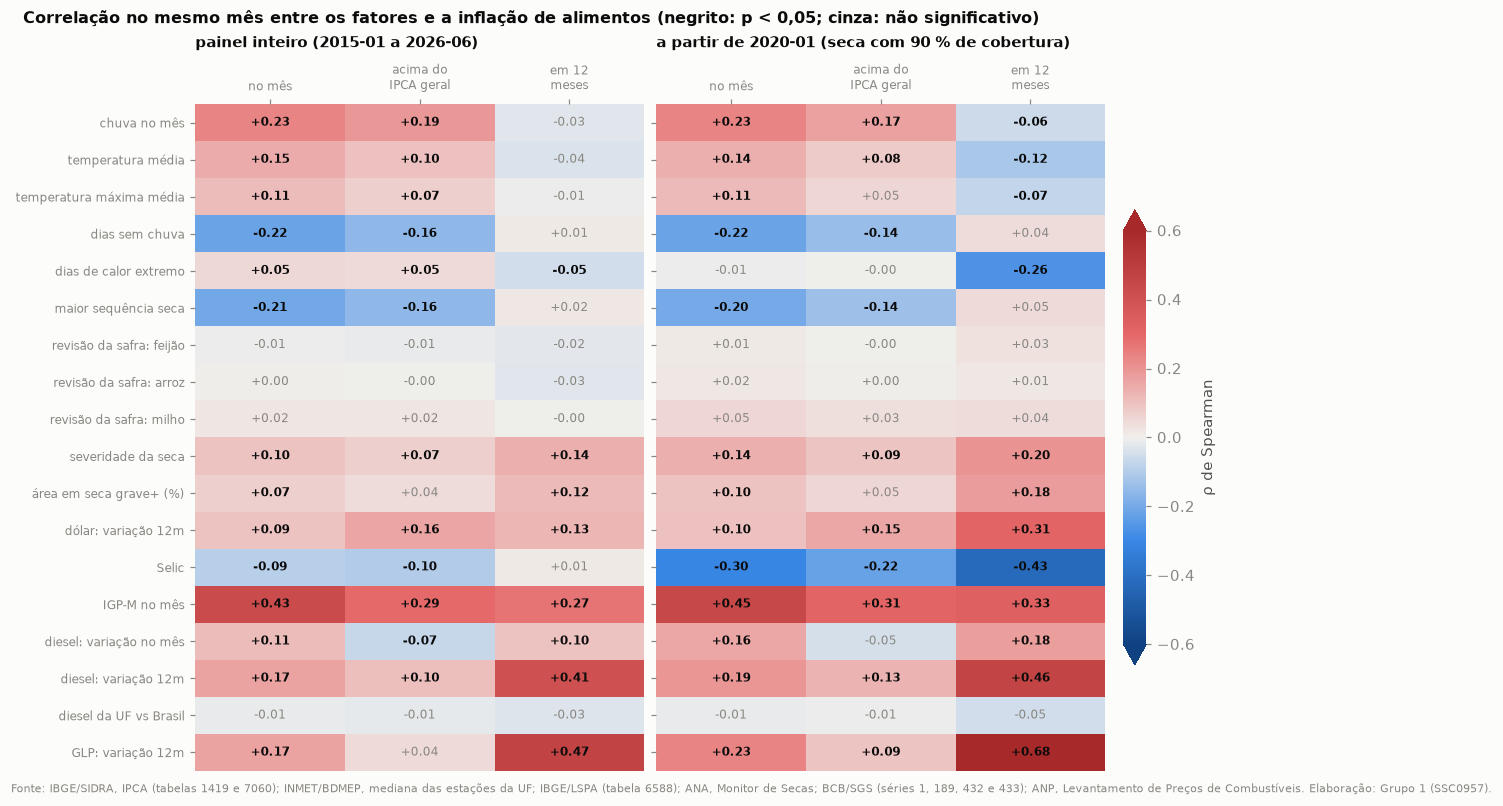

As 10 associações mais fortes a partir de 2020-01:


,fator,alvo,rho,p,n
53,GLP: variação 12m,em 12 meses,0.683,0.0,1216
47,diesel: variação 12m,em 12 meses,0.465,0.0,1049
39,IGP-M no mês,no mês,0.447,0.0,1248
38,Selic,em 12 meses,-0.425,0.0,1248
41,IGP-M no mês,em 12 meses,0.328,0.0,1248
35,dólar: variação 12m,em 12 meses,0.312,0.0,1248
40,IGP-M no mês,acima do IPCA geral,0.310,0.0,1248
36,Selic,no mês,-0.304,0.0,1248
14,dias de calor extremo,em 12 meses,-0.264,0.0,1242
51,GLP: variação 12m,no mês,0.232,0.0,1216


In [26]:
bi = fato.copy()
dolar = bi.drop_duplicates("ano_mes").set_index("ano_mes")["macro_dolar_ptax_medio"]
bi["macro_dolar_var12"] = bi["ano_mes"].map(dolar.pct_change(12, fill_method=None) * 100)

ALVOS = {
    "ipca_var_alimentacao": "no mês",
    "ipca_var_alimentacao_relativa": "acima do\nIPCA geral",
    "ipca_var_alimentacao_acum12": "em 12\nmeses",
}
FATORES = {
    "clima_chuva_mm_mes": "chuva no mês",
    "clima_temp_media": "temperatura média",
    "clima_temp_max_media": "temperatura máxima média",
    "clima_dias_sem_chuva": "dias sem chuva",
    "clima_dias_calor_extremo": "dias de calor extremo",
    "clima_max_dias_secos_seguidos": "maior sequência seca",
    "safra_revisao_pct_feijao": "revisão da safra: feijão",
    "safra_revisao_pct_arroz": "revisão da safra: arroz",
    "safra_revisao_pct_milho": "revisão da safra: milho",
    "seca_severidade_media": "severidade da seca",
    "seca_pct_area_S2plus": "área em seca grave+ (%)",
    "macro_dolar_var12": "dólar: variação 12m",
    "macro_selic": "Selic",
    "macro_igpm": "IGP-M no mês",
    "comb_var_mm_diesel": "diesel: variação no mês",
    "comb_var12_diesel": "diesel: variação 12m",
    "comb_diesel_vs_br_pct": "diesel da UF vs Brasil",
    "comb_var12_glp_13kg": "GLP: variação 12m",
}


def spearman(df, x, y):
    par = df[[x, y]].dropna()
    if len(par) < 30 or par[x].nunique() < 3:
        return np.nan, np.nan, len(par)
    r = stats.spearmanr(par[x], par[y])
    return r.statistic, r.pvalue, len(par)


def matriz(df):
    linhas = [dict(fator=f, alvo=a, **dict(zip(["rho", "p", "n"], spearman(df, f, a))))
              for f in FATORES for a in ALVOS]
    return pd.DataFrame(linhas)


RECORTES = {"painel inteiro (2015-01 a 2026-06)": bi,
            "a partir de 2020-01 (seca com 90 % de cobertura)": bi[bi["ano_mes"] >= pd.Period("2020-01", "M")]}
resultados = {nome: matriz(df) for nome, df in RECORTES.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 7.0), sharey=True, layout="constrained")
for ax, (nome, res) in zip(axes, resultados.items()):
    rho = res.pivot(index="fator", columns="alvo", values="rho").loc[list(FATORES), list(ALVOS)]
    pv = res.pivot(index="fator", columns="alvo", values="p").loc[list(FATORES), list(ALVOS)]
    im = ax.imshow(rho.values, cmap=DIVERGENTE, vmin=-0.6, vmax=0.6, aspect="auto")
    for i in range(rho.shape[0]):
        for j in range(rho.shape[1]):
            v = rho.values[i, j]
            if np.isnan(v):
                continue
            sig = pv.values[i, j] < 0.05
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
                    color=TINTA if sig else TINTA_3, fontweight="bold" if sig else "normal")
    ax.set_xticks(range(len(ALVOS)), list(ALVOS.values()), fontsize=8)
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(FATORES)), list(FATORES.values()), fontsize=8)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(nome, fontsize=9.5, pad=10)
cb = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, extend="both")
cb.set_label("ρ de Spearman")
cb.outline.set_visible(False)
fig.suptitle("Correlação no mesmo mês entre os fatores e a inflação de alimentos "
             "(negrito: p < 0,05; cinza: não significativo)", x=0.01, ha="left", fontweight="bold", fontsize=10.5)
salvar(fig, "21_correlacao_contemporanea", "ipca", "clima", "safra", "seca", "macro", "comb")
plt.show()

top = resultados["a partir de 2020-01 (seca com 90 % de cobertura)"].assign(abs_rho=lambda d: d["rho"].abs())
top["fator"] = top["fator"].map(FATORES)
top["alvo"] = top["alvo"].map(lambda a: ALVOS[a].replace("\n", " "))
print("As 10 associações mais fortes a partir de 2020-01:")
display(top.sort_values("abs_rho", ascending=False).head(10).drop(columns="abs_rho").round(3))

**Leitura:**

1. **As associações mais fortes são com preços amplos, não com clima.** A partir de 2020: GLP em 12 meses
   ρ = 0,68, diesel em 12 meses 0,46, IGP-M no mês 0,45, Selic −0,43, dólar em 12 meses 0,31.
   **Cuidado:** são séries de 12 meses ou nacionais, com o mesmo ciclo de 2020-22 do alvo. Parte dessa
   correlação é só tempo compartilhado (só a mediana mensal do GLP em 12 meses contra a do alvo já dá
   0,66). No alvo relativo, que tira a inflação geral, quase todas enfraquecem.
2. **A Selic negativa é causalidade invertida.** O Banco Central sobe os juros *depois* que a inflação
   sobe, e a inflação cai depois. É um lembrete de que correlação não é efeito.
3. **Clima no mesmo mês:** chuva +0,23 e dias sem chuva −0,22 com o alvo mensal, quase iguais nos dois
   recortes. Isso é a sazonalidade da Parte 4.1 (mês chuvoso, comida cara), e não necessariamente choque
   climático. No acumulado em 12 meses, o clima some.
4. **Seca:** fraca e positiva (+0,10 a +0,20), mais forte no acumulado em 12 meses e a partir de 2020.

**O que não correlacionou:** a revisão de safra (feijão, arroz e milho, ρ ≈ 0 em todos os recortes) e o
diesel relativo (ρ ≈ 0). Não quer dizer que não importem: no mesmo mês e na mesma UF, não aparecem.

### 5.1 Quatro relações de perto, e se elas mudam de região para região

Gráficos de dispersão do alvo em 12 meses contra quatro fatores, um de cada família, cada um na cor da
sua família. Depois, a mesma correlação **separada por região**: é a primeira leitura da hipótese H5
(o efeito muda com a região).

figura salva: outputs/figuras/eda_22_dispersao_alvo_fatores.png


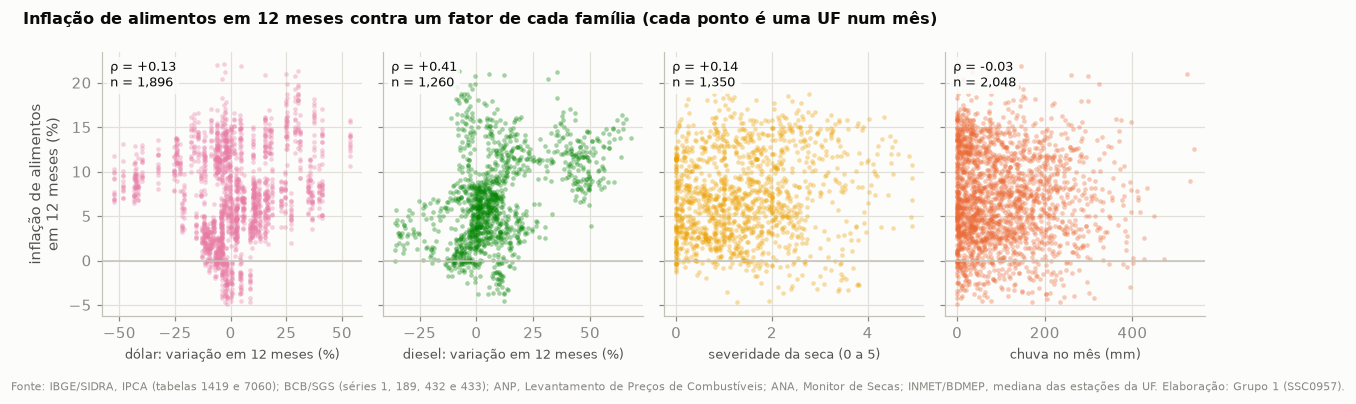

figura salva: outputs/figuras/eda_23_correlacao_por_regiao.png


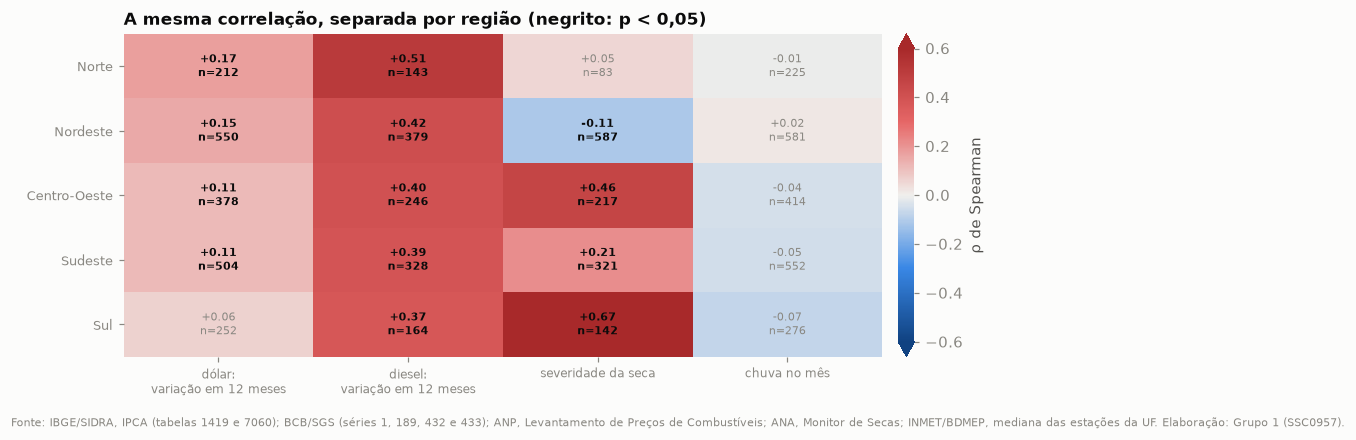

In [27]:
PARES = [
    ("macro_dolar_var12", "dólar: variação em 12 meses (%)", "macro"),
    ("comb_var12_diesel", "diesel: variação em 12 meses (%)", "comb"),
    ("seca_severidade_media", "severidade da seca (0 a 5)", "seca"),
    ("clima_chuva_mm_mes", "chuva no mês (mm)", "clima"),
]
ALVO = "ipca_var_alimentacao_acum12"

fig, axes = plt.subplots(1, 4, figsize=(11, 3.4), sharey=True)
for ax, (col, rot, fam) in zip(axes, PARES):
    par = bi[[col, ALVO]].dropna()
    ax.scatter(par[col], par[ALVO], s=9, color=CORES[fam], alpha=0.35, linewidths=0)
    r, p, n = spearman(bi, col, ALVO)
    ax.text(0.03, 0.97, f"ρ = {r:+.2f}\nn = {n:,}", transform=ax.transAxes, va="top", fontsize=8.5, color=TINTA,
            bbox={"facecolor": FUNDO, "edgecolor": "none", "alpha": 0.85, "pad": 2})
    ax.set_xlabel(rot, fontsize=8.5)
    ax.axhline(0, color=NEUTRO, linewidth=1)
axes[0].set_ylabel("inflação de alimentos\nem 12 meses (%)")
fig.suptitle("Inflação de alimentos em 12 meses contra um fator de cada família (cada ponto é uma UF num mês)",
             x=0.01, ha="left", fontweight="bold", fontsize=10.5)
plt.tight_layout()
salvar(fig, "22_dispersao_alvo_fatores", "ipca", "macro", "comb", "seca", "clima")
plt.show()

linhas = []
for reg in REGIOES:
    sub = bi[bi["regiao"] == reg]
    for col, rot, _ in PARES:
        r, p, n = spearman(sub, col, ALVO)
        linhas.append(dict(regiao=reg, fator=rot.split(" (")[0].replace(": ", ":\n"), rho=r, p=p, n=n))
por_regiao = pd.DataFrame(linhas)
ordem_fatores = list(dict.fromkeys(por_regiao["fator"]))
rho_reg = por_regiao.pivot(index="regiao", columns="fator", values="rho").loc[REGIOES, ordem_fatores]
n_reg = por_regiao.pivot(index="regiao", columns="fator", values="n").loc[REGIOES, ordem_fatores]
p_reg = por_regiao.pivot(index="regiao", columns="fator", values="p").loc[REGIOES, ordem_fatores]

fig, ax = plt.subplots(figsize=(9, 3.8))
im = ax.imshow(rho_reg.values, cmap=DIVERGENTE, vmin=-0.6, vmax=0.6, aspect="auto")
for i in range(rho_reg.shape[0]):
    for j in range(rho_reg.shape[1]):
        v, n, p = rho_reg.values[i, j], n_reg.values[i, j], p_reg.values[i, j]
        if np.isnan(v):
            ax.text(j, i, "sem dado", ha="center", va="center", fontsize=7.5, color=TINTA_3)
            continue
        ax.text(j, i, f"{v:+.2f}\nn={int(n)}", ha="center", va="center", fontsize=7.5,
                color=TINTA if p < 0.05 else TINTA_3, fontweight="bold" if p < 0.05 else "normal")
ax.set_xticks(range(rho_reg.shape[1]), rho_reg.columns, fontsize=8)
ax.set_yticks(range(len(REGIOES)), REGIOES, fontsize=8.5)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, extend="both")
cb.set_label("ρ de Spearman")
cb.outline.set_visible(False)
ax.set_title("A mesma correlação, separada por região (negrito: p < 0,05)")
plt.tight_layout()
salvar(fig, "23_correlacao_por_regiao", "ipca", "macro", "comb", "seca", "clima")
plt.show()

**Leitura:**

- **Dólar:** os pontos formam **faixas verticais** porque o dólar é igual em todas as UFs no mês. Cada
  faixa é um mês, e a altura dentro dela é a diferença entre UFs, que o dólar, por construção, não explica.
- **Diesel em 12 meses:** a relação mais nítida (ρ = 0,41). É parecida nas cinco regiões (0,37 a 0,51) e
  um pouco maior no Norte. Isso é compatível com a hipótese de logística (frete pesa mais longe dos polos
  produtores), mas a diferença entre regiões é pequena demais para afirmar isso sem o T-031.
- **Seca:** o caso mais interessante para H5 (efeito regional). ρ = 0,67 no Sul e 0,46 no Centro-Oeste,
  mas −0,11 no Nordeste. **Cautela:** no Sul a série da seca só começa em 2020, e as estiagens de 2020-22
  coincidiram com o pico nacional da inflação. Pode ser coincidência no tempo, e só defasagem e controle
  pelo mês (T-031) separam as duas coisas.
- **Chuva no mês:** não mostra nada em nenhuma região quando o alvo é o acumulado em 12 meses.

---
## O que fica para os próximos tickets

**Achados principais**

| # | Achado | Número |
|---|---|---|
| 1 | O alvo é sobretudo **nacional**: as UFs se movem juntas | o mês explica 73 % da variância mensal, a UF sozinha 0,1 % |
| 2 | A diferença entre UFs **não é fixa**: o ranking muda | ρ = −0,11 entre as posições de 2018-22 e 2022-26 |
| 3 | As UFs **divergem nos choques** | dispersão × nível da inflação: ρ = 0,71; pico de ~3,1 pp em 2021 |
| 4 | Choques são **assimétricos** e raramente climáticos | 73 choques de alta e 15 de queda; maior: carne em 2019-12 |
| 5 | Há **sazonalidade** forte, alinhada à chuva | dez-jan e mar-abr caros, ago barato; r chuva × preço de 0,64 a 0,80 fora do Sul |
| 6 | No mesmo mês, **preços amplos** correlacionam mais que clima e safra | GLP e diesel 12m 0,46 a 0,68; safra ≈ 0 |

**Para o T-031 (correlação com defasagem)**

| Tema | Encaminhamento |
|---|---|
| Pares para a CCF | seca → alvo (no Sul e Centro-Oeste); diesel 12m → alvo; chuva/dias secos → **tomate, batata e hortaliças** (não só o grupo); revisão de safra → alvo |
| Controle obrigatório | **mês do ano** (sazonalidade) e **efeito do mês** (o ciclo nacional); sem isso, toda série com o ciclo de 2020-22 vai parecer causa |
| Alvo preferido | `ipca_var_alimentacao_relativa`, ou o alvo menos a média nacional do mês, para isolar o componente regional |
| Insumo pronto | `outputs/tabelas/eda_choques_alvo.csv` (88 UF-meses de choque) |

**Para o T-041 (modelagem): recortes e transformações**

| Família | Regra |
|---|---|
| Painel | desbalanceado: AC, MA e SE só a partir de 2018-05; acumulados e rankings só na janela comum |
| Seca | só a partir de 2020-01, ou filtrando `seca_monitorado` |
| Combustíveis | só com `comb_observado_liquidos` / `comb_observado`; nunca interpolar |
| Safra | revisão já winsorizada em ±50 % na junção; `NaN` = "não planta", nunca 0 |
| Clima | levar `clima_n_estacoes` junto (degraus da rede) |
| Macro | explica só o tempo; não usar para diferenças entre UFs |
| Tipos | `seca_meses_consecutivos_S2plus` vem como `Float64` e precisa virar `float64` |

**⭐ As três figuras candidatas à apresentação**

1. `eda_08_heatmap_uf_mes.png`: o ciclo nacional e as variações regionais numa imagem só.
2. `eda_11_dispersao_entre_ufs.png`: as UFs divergem justamente nos choques, que é o centro da pergunta.
3. `eda_15_sazonalidade_chuva_vs_preco.png`: introduz a hipótese clima → preço, com a ressalva escrita.

Alternativa à terceira: `eda_04_alvo_mensal_mediana.png`, a série com os episódios anotados.